# Automated Casting Quality Inspection Workflow (Prepared by Nay Linn Aung)

**Industrial computer vision reference notebook for cast aluminum part inspection**

Primary dataset: Kaggle **Casting Product Image Data for Quality Inspection**

Target architecture: **edge-first ResNet classification gate**, with a controlled extension path to **Ultralytics YOLO detection, segmentation, and oriented bounding boxes** when localized annotations become available.

It is a production-pilot reference template with explicit controls for reproducibility, dataset integrity, threshold governance, error analysis, export validation, drift monitoring, and release readiness.

## 1. Executive Overview

### Problem Statement

Cast aluminum components in automotive manufacturing require repeatable visual inspection for defects such as porosity, blow holes, shrinkage, burrs, inclusions, deformation, surface discontinuities, and other process-related irregularities. Manual inspection varies across operators, shifts, fixtures, camera stations, suppliers, and plants.

The first deployable objective is a **binary part-level inspection gate**:

- **OK**: no visible defect evidence requiring rejection.
- **Defective**: visible defect evidence requiring rejection, rework, or quality engineering review.

The operational priority is minimizing **false accepts** while keeping false rejects within a manageable review/rework load.

### Why This Dataset

The public casting dataset is useful for a pilot template because it contains real industrial casting imagery with image-level labels and a stable folder layout:

```text
casting_data/casting_data/
  train/
    def_front/
    ok_front/
  test/
    def_front/
    ok_front/
```

It is appropriate for a classifier baseline. It is not, by itself, sufficient for production release or localized defect modeling.

### Why This Stack

The inspection architecture is intentionally modular:

- **OpenCV** for deterministic preprocessing, image-quality diagnostics, and edge guardrails.
- **ResNet-family classifier** for fast image-level accept/reject decisions from existing labels.
- **Ultralytics YOLO detection** for localized defect boxes once annotations exist.
- **Ultralytics YOLO segmentation** for defect-area and severity measurement once masks exist.
- **Ultralytics YOLO OBB** for rotated geometry where axis-aligned boxes are too imprecise.

### Scope and Non-Goals

Covered: data validation, leakage checks, preprocessing, augmentation, transfer learning, advanced evaluation, threshold policy, error review, Grad-CAM diagnostics, artifact/export controls, edge latency, drift handling, risks, acceptance criteria, and a model-card summary.

Not covered: PLC/MES integration, certified plant acceptance testing, multi-camera calibration, final defect taxonomy approval, or commercial release based only on public data.


## 2. Assumptions & Constraints

### Data Assumptions

- Dataset is available locally, in Kaggle, or through `CASTING_DATA_ROOT`.
- Labels are image-level binary labels only.
- Public data may include acquisition artifacts, pre-applied augmentation, repeated visual patterns, and distribution shift relative to plant imagery.
- Production release requires plant-owned or properly licensed validation data from the actual station.

### Hardware Assumptions

The intended runtime is edge-first:

- Industrial PC, CPU-only IPC, NVIDIA Jetson-class device, or GPU-enabled edge workstation.
- Batch size 1 inference.
- Deterministic preprocessing.
- Local fail-safe handling for camera faults, unreadable frames, inference failures, and downstream I/O issues.
- Latency measured across the full station path, not only model inference.

### Labeling Limitations

Current labels do not identify defect type, location, count, severity, rework disposition, or visibility from another camera angle. Localization work must begin with new annotations, not assumptions inferred from image-level labels.

### License and Provenance Constraint

The public dataset is suitable for this reference workflow and pilot exploration. Commercial deployment requires license, provenance, privacy, and supplier-data review.


In [1]:
# Code Intent:
# Establish a reliable runtime before any dataset or model work begins.
# Key Ideas:
# - Separate mandatory dependencies from optional integrations so the notebook fails only on true blockers.
# - Record package, Python, platform, CUDA, and seed details for reproducibility and audit review.
# - Force deterministic PyTorch behavior where practical so repeated pilot runs are comparable.
# - Select CPU/GPU automatically while making the selected device visible to reviewers.
# - Build a preflight report that later becomes part of the experiment manifest.

# Environment, versions, deterministic controls, and runtime preflight

from __future__ import annotations

import copy
import hashlib
import importlib
import importlib.metadata as importlib_metadata
import importlib.util
import json
import math
import os
import platform
import random
import subprocess
import sys
import time
import warnings
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

REQUIRED_MODULES = {
    "cv2": "opencv-python",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "PIL": "Pillow",
    "sklearn": "scikit-learn",
    "torch": "torch",
    "torchvision": "torchvision",
}
OPTIONAL_MODULES = {
    "onnx": "onnx",
    "onnxruntime": "onnxruntime",
    "ultralytics": "ultralytics",
    "kagglehub": "kagglehub",
}

missing = [
    pip_name
    for module_name, pip_name in REQUIRED_MODULES.items()
    if importlib.util.find_spec(module_name) is None
]
if missing:
    raise ImportError(
        "Missing required packages: "
        + ", ".join(missing)
        + ". Install them in the notebook environment before executing the workflow."
    )

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

def parse_bool_env(name: str, default: bool = False) -> bool:
    raw = os.getenv(name)
    if raw is None:
        return default
    return raw.strip().lower() in {"1", "true", "yes", "y", "on"}

def package_version(distribution_name: str) -> str:
    try:
        return importlib_metadata.version(distribution_name)
    except importlib_metadata.PackageNotFoundError:
        return "not-installed"

PACKAGE_VERSIONS = {
    pip_name: package_version(pip_name)
    for pip_name in {**REQUIRED_MODULES, **OPTIONAL_MODULES}.values()
}

SEED = int(os.getenv("CASTING_INSPECTION_SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

preflight_report = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(),
    "platform": platform.platform(),
    "device": str(DEVICE),
    "cuda_available": torch.cuda.is_available(),
    "seed": SEED,
    "package_versions": PACKAGE_VERSIONS,
}
display(pd.DataFrame([preflight_report]).drop(columns=["package_versions"]))
display(pd.DataFrame([PACKAGE_VERSIONS]).T.rename(columns={0: "version"}))


,timestamp_utc,python,platform,device,cuda_available,seed
0,2026-05-01T02:21:16.393212+00:00,3.12.13,Linux-6.6.113+-x86_64-with-glibc2.35,cuda,True,42


,version
opencv-python,4.13.0.92
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
Pillow,11.3.0
scikit-learn,1.6.1
torch,2.10.0+cu128
torchvision,0.25.0+cu128
onnx,not-installed
onnxruntime,not-installed


In [2]:
# Code Intent:
# Centralize all operational knobs into typed configuration objects.
# Key Ideas:
# - Keep dataset, training, preprocessing, edge, and artifact settings separate to avoid hidden coupling.
# - Allow important runtime switches to be controlled by environment variables for CI/Kaggle/edge use.
# - Make Colab dataset setup robust by supporting explicit roots, recursive discovery, and optional KaggleHub download.
# - Keep artifact writing and ONNX export disabled by default so review runs do not create unexpected files.
# - Define stable label mappings once so metrics, thresholds, logging, and artifacts use the same contract.
# - Store commonly documented Kaggle counts as warnings, not hard failures, because dataset variants exist.

# Configuration dataclasses

@dataclass(frozen=True)
class DatasetConfig:
    root_env_var: str = "CASTING_DATA_ROOT"
    kaggle_dataset_slug: str = "ravirajsinh45/real-life-industrial-dataset-of-casting-product"
    auto_download_dataset: bool = parse_bool_env("AUTO_DOWNLOAD_CASTING_DATASET", True)
    install_kagglehub_if_missing: bool = parse_bool_env("INSTALL_KAGGLEHUB_IF_MISSING", True)
    image_extensions: Tuple[str, ...] = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    val_fraction_from_train: float = 0.15
    max_audit_images: Optional[int] = None
    max_near_duplicate_images: int = 1500
    near_duplicate_hamming_threshold: int = 4
    expected_public_counts_enabled: bool = True

@dataclass(frozen=True)
class TrainingConfig:
    image_size: int = 224
    batch_size: int = 32
    num_workers: int = 0
    epochs: int = 5
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    use_weighted_sampler: bool = True
    use_class_weighted_loss: bool = False
    defect_positive_label: int = 1
    defect_recall_target: float = 0.95
    threshold_grid_points: int = 91
    run_one_batch_smoke_test: bool = parse_bool_env("RUN_ONE_BATCH_SMOKE_TEST", False)

@dataclass(frozen=True)
class PreprocessConfig:
    use_clahe: bool = True
    denoise: bool = False
    clahe_clip_limit: float = 2.0
    clahe_tile_grid_size: Tuple[int, int] = (8, 8)

@dataclass(frozen=True)
class EdgeConfig:
    p95_latency_budget_ms: float = float(os.getenv("EDGE_P95_LATENCY_BUDGET_MS", "50"))
    benchmark_repeats: int = 50
    benchmark_warmup: int = 10
    batch_size_one_required: bool = True

@dataclass(frozen=True)
class ArtifactConfig:
    root: Path = Path(os.getenv("CASTING_ARTIFACT_ROOT", "artifacts/casting_inspection"))
    save_artifacts: bool = parse_bool_env("SAVE_CASTING_ARTIFACTS", False)
    export_onnx: bool = parse_bool_env("EXPORT_CASTING_ONNX", False)
    validate_onnx_parity: bool = parse_bool_env("VALIDATE_ONNX_PARITY", True)

DATASET_CONFIG = DatasetConfig()
TRAINING_CONFIG = TrainingConfig()
PREPROCESS_CONFIG = PreprocessConfig()
EDGE_CONFIG = EdgeConfig()
ARTIFACT_CONFIG = ArtifactConfig()

CLASS_TO_INDEX = {"ok_front": 0, "def_front": 1}
INDEX_TO_CLASS = {value: key for key, value in CLASS_TO_INDEX.items()}
DISPLAY_NAMES = {0: "OK", 1: "Defective"}
DEFECT_CLASSES = {0: "casting_defect"}

PREPROCESS_VERSION = os.getenv("CASTING_PREPROCESS_VERSION", "opencv-clahe-v2")
MODEL_VERSION = os.getenv("CASTING_MODEL_VERSION", "resnet18-imagelevel-public-pilot-v1")
NOTEBOOK_RELEASE_STATUS = "pilot_reference_not_production_approved"
LEAKAGE_POLICY = {
    "priority_order": ["train", "val", "test"],
    "train_val_overlap_action": "remove_from_validation",
    "test_overlap_action": "remove_from_test",
    "filename_overlap": "drop_downstream_rows_matching_upstream_filenames",
    "exact_hash_overlap": "drop_downstream_rows_matching_upstream_sha1",
    "near_duplicate_overlap": "warn_and_review_only",
}

EXPECTED_PUBLIC_COUNTS = {
    ("train", "def_front"): 3758,
    ("train", "ok_front"): 2875,
    ("test", "def_front"): 453,
    ("test", "ok_front"): 262,
}

configuration_report = {
    "workflow": {
        "model_version": MODEL_VERSION,
        "preprocess_version": PREPROCESS_VERSION,
        "notebook_release_status": NOTEBOOK_RELEASE_STATUS,
        "leakage_policy": LEAKAGE_POLICY,
    },
    "dataset": asdict(DATASET_CONFIG),
    "training": asdict(TRAINING_CONFIG),
    "preprocess": asdict(PREPROCESS_CONFIG),
    "edge": asdict(EDGE_CONFIG),
    "artifact": {**asdict(ARTIFACT_CONFIG), "root": str(ARTIFACT_CONFIG.root)},
}
display(pd.DataFrame([configuration_report]).T.rename(columns={0: "value"}))


,value
workflow,{'model_version': 'resnet18-imagelevel-public-...
dataset,"{'root_env_var': 'CASTING_DATA_ROOT', 'kaggle_..."
training,"{'image_size': 224, 'batch_size': 32, 'num_wor..."
preprocess,"{'use_clahe': True, 'denoise': False, 'clahe_c..."
edge,"{'p95_latency_budget_ms': 50.0, 'benchmark_rep..."
artifact,"{'root': 'artifacts/casting_inspection', 'save..."


In [3]:
# Code Intent:
# Create a compact run manifest that can travel with metrics and model artifacts.
# Key Ideas:
# - Capture git commit when available without requiring the notebook to live inside a repository.
# - Convert Paths, NumPy scalars, tuples, and nested config values into JSON-safe objects.
# - Persist seed, device, package versions, and configuration in one object for traceability.
# - Use the manifest later when saving artifacts so model, threshold, and metrics remain linked.

# Run manifest utilities

def current_git_commit() -> Optional[str]:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"],
            stderr=subprocess.DEVNULL,
            text=True,
        ).strip()
    except Exception:
        return None

def json_safe(payload):
    if isinstance(payload, Path):
        return str(payload)
    if isinstance(payload, dict):
        return {str(key): json_safe(value) for key, value in payload.items()}
    if isinstance(payload, (list, tuple)):
        return [json_safe(value) for value in payload]
    if isinstance(payload, np.generic):
        return payload.item()
    return payload

RUN_MANIFEST = {
    "workflow": "casting_inspection_industrial_workflow",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "seed": SEED,
    "device": str(DEVICE),
    "git_commit": current_git_commit(),
    "model_version": MODEL_VERSION,
    "preprocess_version": PREPROCESS_VERSION,
    "notebook_release_status": NOTEBOOK_RELEASE_STATUS,
    "leakage_policy": json_safe(LEAKAGE_POLICY),
    "package_versions": PACKAGE_VERSIONS,
    "configuration": json_safe(configuration_report),
}

display(pd.DataFrame([RUN_MANIFEST]).drop(columns=["package_versions", "configuration"]))


,workflow,created_utc,seed,device,git_commit,model_version,preprocess_version,notebook_release_status,leakage_policy
0,casting_inspection_industrial_workflow,2026-05-01T02:21:16.467442+00:00,42,cuda,None,resnet18-imagelevel-public-pilot-v1,opencv-clahe-v2,pilot_reference_not_production_approved,"{'priority_order': ['train', 'val', 'test'], '..."


## 3. Dataset Exploration

Dataset exploration is a production control point. The notebook validates folder layout, class balance, expected public counts, image readability, dimensions, exact hash leakage, and near-duplicate average-hash risk.


### Colab Dataset Setup Behavior

This notebook now handles the most common Colab dataset failure mode. It first honors `CASTING_DATA_ROOT`, then searches common Kaggle, Colab, and KaggleHub cache locations. If the dataset is still missing and `AUTO_DOWNLOAD_CASTING_DATASET=True`, it attempts to download the public Kaggle dataset with `kagglehub`.

If an organization disables automatic downloads, set `AUTO_DOWNLOAD_CASTING_DATASET=False` and set `CASTING_DATA_ROOT` manually to the folder that contains `train/` and `test/`.


In [4]:
# Code Intent:
# Resolve the physical dataset location in a way that works locally, on Kaggle, and in Google Colab.
# Key Ideas:
# - Prefer CASTING_DATA_ROOT when supplied because production pilots should use explicit data roots.
# - Probe common Kaggle, Colab, local, and KaggleHub cache paths before attempting downloads.
# - Recursively discover nested casting_data folders because KaggleHub often caches datasets under versioned directories.
# - Optionally auto-download the public Kaggle dataset with kagglehub so Colab runs do not fail at setup.
# - Display diagnostics for every candidate path and fail with actionable guidance if download/search cannot resolve the data.

# Dataset root resolution

IMAGE_EXTENSIONS = set(DATASET_CONFIG.image_extensions)

def running_in_colab() -> bool:
    return importlib.util.find_spec("google.colab") is not None or Path("/content").exists()

def is_dataset_root(path: Path) -> bool:
    return all((path / split / class_name).exists() for split in ["train", "test"] for class_name in CLASS_TO_INDEX)

def unique_existing_paths(paths: Sequence[Path]) -> List[Path]:
    seen = set()
    unique = []
    for path in paths:
        try:
            resolved = path.expanduser().resolve()
        except Exception:
            resolved = path.expanduser()
        key = str(resolved)
        if key not in seen:
            seen.add(key)
            unique.append(resolved)
    return unique

def candidate_dataset_roots(extra_roots: Optional[Sequence[Path]] = None) -> List[Path]:
    env_root = os.getenv(DATASET_CONFIG.root_env_var)
    candidates = []
    if env_root:
        env_path = Path(env_root)
        candidates.extend([env_path, env_path / "casting_data", env_path / "casting_data" / "casting_data"])

    candidates.extend(
        [
            Path("/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data"),
            Path("/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data"),
            Path("/content/casting_data/casting_data"),
            Path("/content/casting_data"),
            Path.cwd() / "casting_data" / "casting_data",
            Path.cwd() / "casting_data",
            Path.cwd(),
            Path.home() / ".cache" / "kagglehub" / "datasets" / "ravirajsinh45" / "real-life-industrial-dataset-of-casting-product",
        ]
    )

    if extra_roots:
        for root in extra_roots:
            candidates.extend([root, root / "casting_data", root / "casting_data" / "casting_data"])

    return unique_existing_paths(candidates)

def discover_dataset_roots(search_bases: Sequence[Path], max_matches: int = 25) -> List[Path]:
    discovered = []
    for base in unique_existing_paths(search_bases):
        if not base.exists() or not base.is_dir():
            continue
        direct_candidates = [base, base / "casting_data", base / "casting_data" / "casting_data"]
        for candidate in direct_candidates:
            if is_dataset_root(candidate):
                discovered.append(candidate)
        try:
            for casting_dir in base.rglob("casting_data"):
                for candidate in [casting_dir, casting_dir / "casting_data"]:
                    if is_dataset_root(candidate):
                        discovered.append(candidate)
                        if len(discovered) >= max_matches:
                            return unique_existing_paths(discovered)
        except (OSError, PermissionError):
            continue
    return unique_existing_paths(discovered)

def ensure_kagglehub_available() -> bool:
    if importlib.util.find_spec("kagglehub") is not None:
        return True
    if not DATASET_CONFIG.install_kagglehub_if_missing:
        return False
    print("kagglehub is not installed. Installing kagglehub for Colab dataset download...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
    importlib.invalidate_caches()
    return importlib.util.find_spec("kagglehub") is not None

def download_dataset_with_kagglehub() -> Optional[Path]:
    if not DATASET_CONFIG.auto_download_dataset:
        return None
    try:
        if not ensure_kagglehub_available():
            warnings.warn("kagglehub is unavailable. Automatic dataset download was skipped.")
            return None
        import kagglehub

        print(f"Downloading Kaggle dataset: {DATASET_CONFIG.kaggle_dataset_slug}")
        downloaded_path = Path(kagglehub.dataset_download(DATASET_CONFIG.kaggle_dataset_slug)).resolve()
        print(f"KaggleHub download/cache path: {downloaded_path}")
        return downloaded_path
    except Exception as exc:
        warnings.warn(f"Automatic KaggleHub dataset download failed: {exc}")
        return None

def resolve_dataset_root() -> Path:
    diagnostics = []

    initial_candidates = candidate_dataset_roots()
    search_bases = initial_candidates + [Path("/content"), Path("/kaggle/input"), Path.home() / ".cache" / "kagglehub"]
    discovered = discover_dataset_roots(search_bases)

    for path in unique_existing_paths(initial_candidates + discovered):
        diagnostics.append({"phase": "search", "candidate": str(path), "exists": path.exists(), "is_dataset_root": is_dataset_root(path)})
        if is_dataset_root(path):
            display(pd.DataFrame(diagnostics))
            return path.resolve()

    downloaded_path = download_dataset_with_kagglehub()
    if downloaded_path is not None:
        post_download_candidates = candidate_dataset_roots(extra_roots=[downloaded_path])
        post_download_discovered = discover_dataset_roots([downloaded_path, downloaded_path.parent, Path.home() / ".cache" / "kagglehub"])
        for path in unique_existing_paths(post_download_candidates + post_download_discovered):
            diagnostics.append({"phase": "post_download", "candidate": str(path), "exists": path.exists(), "is_dataset_root": is_dataset_root(path)})
            if is_dataset_root(path):
                display(pd.DataFrame(diagnostics))
                return path.resolve()

    display(pd.DataFrame(diagnostics))
    searched = "\n".join(str(path) for path in unique_existing_paths(candidate_dataset_roots()))
    raise FileNotFoundError(
        f"Could not find the casting dataset root. Set {DATASET_CONFIG.root_env_var} to the directory containing "
        "train/ and test/ folders with def_front/ and ok_front/ subfolders. In Colab, either allow the "
        "automatic KaggleHub download or run: \n"
        "    import os, kagglehub\n"
        f"    path = kagglehub.dataset_download('{DATASET_CONFIG.kaggle_dataset_slug}')\n"
        f"    os.environ['{DATASET_CONFIG.root_env_var}'] = path\n\n"
        "Searched:\n" + searched
    )

DATA_ROOT = resolve_dataset_root()
RUN_MANIFEST["dataset_root"] = str(DATA_ROOT)
print(DATA_ROOT)


,phase,candidate,exists,is_dataset_root
0,search,/kaggle/input/real-life-industrial-dataset-of-...,True,True


/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data


,split,class_name,display_label,count
0,test,def_front,Defective,453
1,test,ok_front,OK,262
2,train,def_front,Defective,3758
3,train,ok_front,OK,2875


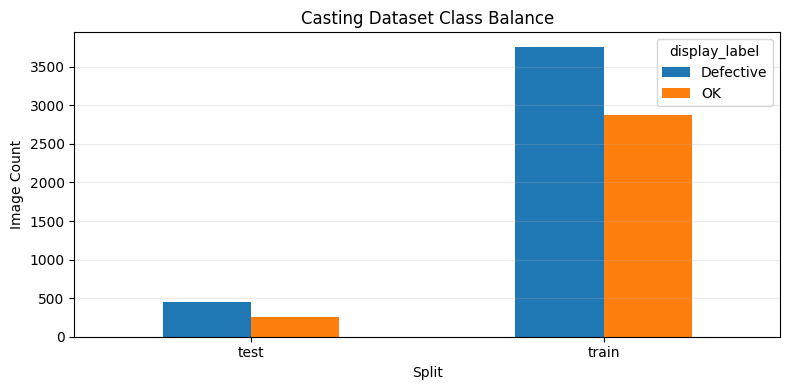

In [5]:
# Code Intent:
# Convert the folder tree into a tabular image inventory and inspect class balance.
# Key Ideas:
# - Use the directory name as the source of truth for binary labels.
# - Keep file path, filename, split, class name, numeric label, and display label together for auditability.
# - Warn when counts differ from the common public split without blocking legitimate dataset variants.
# - Plot class balance because defect/OK imbalance affects sampling, loss design, and threshold policy.

# Image inventory, expected counts, and class balance

def list_images(root: Path, split: str) -> pd.DataFrame:
    records = []
    for class_name, label in CLASS_TO_INDEX.items():
        class_dir = root / split / class_name
        for path in sorted(class_dir.rglob("*")):
            if path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append(
                    {
                        "path": str(path),
                        "file_name": path.name,
                        "split": split,
                        "class_name": class_name,
                        "label": label,
                        "display_label": DISPLAY_NAMES[label],
                    }
                )
    return pd.DataFrame.from_records(records)

raw_train_df = list_images(DATA_ROOT, "train")
test_df = list_images(DATA_ROOT, "test")
dataset_df = pd.concat([raw_train_df, test_df], ignore_index=True)

if dataset_df.empty:
    raise ValueError(f"No image files found under {DATA_ROOT}")

class_counts = (
    dataset_df.groupby(["split", "class_name", "display_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "class_name"])
)
display(class_counts)

if DATASET_CONFIG.expected_public_counts_enabled:
    observed = {(row.split, row.class_name): int(row.count) for row in class_counts.itertuples(index=False)}
    expected_warnings = []
    for key, expected_count in EXPECTED_PUBLIC_COUNTS.items():
        actual_count = observed.get(key)
        if actual_count != expected_count:
            expected_warnings.append({"split": key[0], "class_name": key[1], "expected": expected_count, "actual": actual_count})
    if expected_warnings:
        warnings.warn("Dataset counts differ from the commonly documented Kaggle split. Review before comparing metrics.")
        display(pd.DataFrame(expected_warnings))

pivot_counts = class_counts.pivot(index="split", columns="display_label", values="count").fillna(0)
ax = pivot_counts.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Casting Dataset Class Balance")
ax.set_xlabel("Split")
ax.set_ylabel("Image Count")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [6]:
# Code Intent:
# Create a validation split and keep initial split accounting separate from final leakage-filtered accounting.
# Key Ideas:
# - Use stratification so defective and OK proportions remain stable across training and validation.
# - Keep the public test split isolated for final evaluation after threshold selection.
# - Store initial split counts before leakage policy, then recompute final counts after filtering.
# - Provide reusable split-summary helpers so downstream reporting always uses the same contract.

# Train/validation split from provided training data

def build_model_split_frame(train_frame: pd.DataFrame, val_frame: pd.DataFrame, test_frame: pd.DataFrame) -> pd.DataFrame:
    frames = []
    for split_name, frame in [("train", train_frame), ("val", val_frame), ("test", test_frame)]:
        working = frame.reset_index(drop=True).copy()
        working["model_split"] = split_name
        frames.append(working)
    return pd.concat(frames, ignore_index=True)

def build_split_count_table(train_frame: pd.DataFrame, val_frame: pd.DataFrame, test_frame: pd.DataFrame) -> pd.DataFrame:
    split_summary = build_model_split_frame(train_frame, val_frame, test_frame)
    return (
        split_summary.groupby(["model_split", "display_label"])
        .size()
        .reset_index(name="count")
        .sort_values(["model_split", "display_label"])
    )

train_df, val_df = train_test_split(
    raw_train_df,
    test_size=DATASET_CONFIG.val_fraction_from_train,
    stratify=raw_train_df["label"],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

initial_split_count_table = build_split_count_table(train_df, val_df, test_df)
display(initial_split_count_table)
RUN_MANIFEST["initial_split_counts"] = initial_split_count_table.to_dict(orient="records")


,model_split,display_label,count
0,test,Defective,453
1,test,OK,262
2,train,Defective,3194
3,train,OK,2444
4,val,Defective,564
5,val,OK,431


In [7]:
# Code Intent:
# Detect common industrial dataset quality risks before training.
# Key Ideas:
# - Audit image readability, shape, channels, and dtype to catch acquisition or unpacking issues.
# - Compute SHA-1 hashes to identify exact duplicate files that cross train/test boundaries.
# - Compute simple average hashes to flag possible near-duplicates across splits.
# - Treat near-duplicate results as review evidence, not automatic deletion, because augmented industrial images may be legitimate.
# - Add pre-policy audit results to the manifest, then final leakage status is recomputed after filtering.

# Image readability, exact hash leakage, and near-duplicate average-hash checks

def inspect_image(path: str) -> Dict[str, object]:
    image = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if image is None:
        return {"readable": False, "height": None, "width": None, "channels": None, "dtype": None}
    if image.ndim == 2:
        height, width = image.shape
        channels = 1
    else:
        height, width, channels = image.shape
    return {"readable": True, "height": int(height), "width": int(width), "channels": int(channels), "dtype": str(image.dtype)}

def sha1_file(path: str, block_size: int = 1024 * 1024) -> Optional[str]:
    digest = hashlib.sha1()
    try:
        with open(path, "rb") as handle:
            while True:
                block = handle.read(block_size)
                if not block:
                    break
                digest.update(block)
        return digest.hexdigest()
    except OSError:
        return None

def average_hash(path: str, hash_size: int = 8) -> Optional[str]:
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None
    small = cv2.resize(image, (hash_size, hash_size), interpolation=cv2.INTER_AREA)
    bits = (small > small.mean()).astype(np.uint8).flatten()
    value = 0
    for bit in bits:
        value = (value << 1) | int(bit)
    return f"{value:016x}"

def hamming_hex(left: str, right: str) -> int:
    return (int(left, 16) ^ int(right, 16)).bit_count()

def attach_image_hashes(df: pd.DataFrame, include_average_hash: bool = False) -> pd.DataFrame:
    """Attach deterministic image hashes used for leakage auditing."""
    frame = df.reset_index(drop=True).copy()
    if "sha1" not in frame.columns or frame["sha1"].isna().any():
        frame["sha1"] = [sha1_file(path) for path in frame["path"]]
    if include_average_hash and ("ahash" not in frame.columns or frame["ahash"].isna().any()):
        frame["ahash"] = [average_hash(path) for path in frame["path"]]
    return frame

def cross_split_overlap_frame(named_frames: Sequence[Tuple[str, pd.DataFrame]], key_column: str) -> pd.DataFrame:
    rows = []
    prepared = []
    for split_name, frame in named_frames:
        if key_column not in frame.columns:
            frame = attach_image_hashes(frame) if key_column == "sha1" else frame.copy()
        prepared.append((split_name, frame))
    for i, (left_name, left_frame) in enumerate(prepared):
        left_values = set(left_frame[key_column].dropna().tolist())
        for right_name, right_frame in prepared[i + 1:]:
            right_values = set(right_frame[key_column].dropna().tolist())
            overlap = sorted(left_values.intersection(right_values))
            if overlap:
                rows.append(
                    {
                        "left_split": left_name,
                        "right_split": right_name,
                        "key_column": key_column,
                        "overlap_count": len(overlap),
                        "examples": overlap[:10],
                    }
                )
    return pd.DataFrame(rows)

scan_df = dataset_df.copy()
if DATASET_CONFIG.max_audit_images is not None:
    scan_df = scan_df.sample(min(DATASET_CONFIG.max_audit_images, len(scan_df)), random_state=SEED)

audit_df = pd.DataFrame([{"path": path, **inspect_image(path)} for path in scan_df["path"].tolist()])
audit_summary = {
    "scanned_images": len(audit_df),
    "unreadable_images": int((~audit_df["readable"]).sum()),
    "unique_shape_count": int(audit_df[["height", "width", "channels"]].drop_duplicates().shape[0]),
}
print(audit_summary)
display(audit_df[["height", "width", "channels", "dtype"]].value_counts().reset_index(name="count").head(20))

dataset_df = attach_image_hashes(dataset_df)
exact_hash_groups = (
    dataset_df.dropna(subset=["sha1"])
    .groupby("sha1")
    .agg(split_count=("split", "nunique"), sample_count=("path", "count"), examples=("path", lambda values: list(values)[:3]))
    .reset_index()
)
exact_hash_leaks = exact_hash_groups[(exact_hash_groups["split_count"] > 1) & (exact_hash_groups["sample_count"] > 1)]
print(f"Pre-policy exact public train/test hash leak groups: {len(exact_hash_leaks)}")
display(exact_hash_leaks.head(20))

hash_sample_df = dataset_df.sample(min(DATASET_CONFIG.max_near_duplicate_images, len(dataset_df)), random_state=SEED).copy()
hash_sample_df = attach_image_hashes(hash_sample_df, include_average_hash=True)
hash_records = hash_sample_df.dropna(subset=["ahash"])[["path", "split", "display_label", "ahash"]].to_dict("records")
near_duplicate_pairs = []
for i, left in enumerate(hash_records):
    for right in hash_records[i + 1:]:
        if left["split"] == right["split"]:
            continue
        distance = hamming_hex(left["ahash"], right["ahash"])
        if distance <= DATASET_CONFIG.near_duplicate_hamming_threshold:
            near_duplicate_pairs.append(
                {
                    "left_split": left["split"],
                    "right_split": right["split"],
                    "left_label": left["display_label"],
                    "right_label": right["display_label"],
                    "hamming": distance,
                    "left_path": left["path"],
                    "right_path": right["path"],
                }
            )
        if len(near_duplicate_pairs) >= 25:
            break
    if len(near_duplicate_pairs) >= 25:
        break

near_duplicate_df = pd.DataFrame(near_duplicate_pairs)
print(f"Near-duplicate cross-split average-hash pairs shown for review: {len(near_duplicate_df)}")
display(near_duplicate_df)
RUN_MANIFEST["audit_summary"] = audit_summary
RUN_MANIFEST["pre_policy_exact_hash_leak_groups"] = int(len(exact_hash_leaks))
RUN_MANIFEST["near_duplicate_pairs_shown"] = int(len(near_duplicate_df))


{'scanned_images': 7348, 'unreadable_images': 0, 'unique_shape_count': 1}


,height,width,channels,dtype,count
0,300,300,3,uint8,7348


Pre-policy exact public train/test hash leak groups: 64


,sha1,split_count,sample_count,examples
154,053c2bdec20390796a8454ae83b647c14ade04c4,2,2,[/kaggle/input/real-life-industrial-dataset-of...
188,065593bfd02b435290141d4be3b8a034ec2e93a6,2,2,[/kaggle/input/real-life-industrial-dataset-of...
251,08c79bef293e30458e58c290e6ff26d67fc28b8a,2,2,[/kaggle/input/real-life-industrial-dataset-of...
274,09b1030d661d31f214919a3c6880189335ee56f2,2,2,[/kaggle/input/real-life-industrial-dataset-of...
305,0a7e040113f70e3ea05405c178ad746e9d9a532b,2,2,[/kaggle/input/real-life-industrial-dataset-of...
417,0e91985482f497c4ade0452631904a41e201b60c,2,2,[/kaggle/input/real-life-industrial-dataset-of...
537,12dadbb59bfcdd456e77e6acaabdd26f60b3f171,2,2,[/kaggle/input/real-life-industrial-dataset-of...
712,1903b34861b9d8e9568762e0952dc70b0e8ac648,2,2,[/kaggle/input/real-life-industrial-dataset-of...
718,1946bc9c44a82351df367583d9983db662b0c804,2,2,[/kaggle/input/real-life-industrial-dataset-of...
1109,272291cbd914ff084cd0a00adbe45962617582ee,2,2,[/kaggle/input/real-life-industrial-dataset-of...


Near-duplicate cross-split average-hash pairs shown for review: 25


,left_split,right_split,left_label,right_label,hamming,left_path,right_path
0,train,test,Defective,Defective,4,/kaggle/input/real-life-industrial-dataset-of-...,/kaggle/input/real-life-industrial-dataset-of-...
1,train,test,Defective,Defective,2,/kaggle/input/real-life-industrial-dataset-of-...,/kaggle/input/real-life-industrial-dataset-of-...
2,train,test,Defective,OK,4,/kaggle/input/real-life-industrial-dataset-of-...,/kaggle/input/real-life-industrial-dataset-of-...
3,train,test,Defective,OK,3,/kaggle/input/real-life-industrial-dataset-of-...,/kaggle/input/real-life-industrial-dataset-of-...
4,train,test,Defective,Defective,4,/kaggle/input/real-life-industrial-dataset-of-...,/kaggle/input/real-life-industrial-dataset-of-...
5,train,test,Defective,Defective,4,/kaggle/input/real-life-industrial-dataset-of-...,/kaggle/input/real-life-industrial-dataset-of-...
6,train,test,Defective,Defective,4,/kaggle/input/real-life-industrial-dataset-of-...,/kaggle/input/real-life-industrial-dataset-of-...
7,train,test,Defective,Defective,3,/kaggle/input/real-life-industrial-dataset-of-...,/kaggle/input/real-life-industrial-dataset-of-...
8,train,test,Defective,Defective,3,/kaggle/input/real-life-industrial-dataset-of-...,/kaggle/input/real-life-industrial-dataset-of-...
9,train,test,Defective,Defective,3,/kaggle/input/real-life-industrial-dataset-of-...,/kaggle/input/real-life-industrial-dataset-of-...


In [8]:
# Code Intent:
# Apply auditable split leakage policy before any model training occurs.
# Key Ideas:
# - Treat train as the anchor split, then remove downstream validation/test rows that overlap by filename or exact SHA-1.
# - Recompute final split counts and final leakage checks after filtering.
# - Keep near-duplicate average-hash findings as warnings for quality review, not automatic deletion.
# - Store final leakage policy, removals, split counts, and pass/fail status in the run manifest.

# Final split leakage policy and assertions

def assert_no_filename_leakage(*named_frames: Tuple[str, pd.DataFrame]) -> None:
    leakage_df = cross_split_overlap_frame(named_frames, "file_name")
    if not leakage_df.empty:
        raise AssertionError(f"Potential filename leakage detected: {leakage_df.to_dict(orient='records')}")

def assert_no_hash_leakage(*named_frames: Tuple[str, pd.DataFrame]) -> None:
    hashed_frames = [(name, attach_image_hashes(frame)) for name, frame in named_frames]
    leakage_df = cross_split_overlap_frame(hashed_frames, "sha1")
    if not leakage_df.empty:
        raise AssertionError(f"Potential exact-hash leakage detected: {leakage_df.to_dict(orient='records')}")

def _drop_downstream_overlaps(
    candidate_frame: pd.DataFrame,
    candidate_name: str,
    upstream_frames: Sequence[Tuple[str, pd.DataFrame]],
) -> Tuple[pd.DataFrame, List[Dict[str, object]]]:
    upstream_filenames = set()
    upstream_hashes = set()
    upstream_names_by_hash = {}
    for upstream_name, upstream_frame in upstream_frames:
        upstream_filenames.update(upstream_frame["file_name"].dropna().tolist())
        for sha1 in upstream_frame["sha1"].dropna().tolist():
            upstream_hashes.add(sha1)
            upstream_names_by_hash.setdefault(sha1, set()).add(upstream_name)

    filename_overlap = candidate_frame["file_name"].isin(upstream_filenames)
    hash_overlap = candidate_frame["sha1"].notna() & candidate_frame["sha1"].isin(upstream_hashes)
    remove_mask = filename_overlap | hash_overlap

    removal_records = []
    for _, row in candidate_frame.loc[remove_mask].iterrows():
        reasons = []
        if bool(row["file_name"] in upstream_filenames):
            reasons.append("filename_overlap")
        if pd.notna(row["sha1"]) and row["sha1"] in upstream_hashes:
            reasons.append("exact_hash_overlap")
        removal_records.append(
            {
                "removed_from": candidate_name,
                "file_name": row["file_name"],
                "display_label": row["display_label"],
                "sha1": row.get("sha1"),
                "reason": "+".join(reasons),
                "upstream_hash_splits": sorted(upstream_names_by_hash.get(row.get("sha1"), [])),
                "path": row["path"],
            }
        )
    return candidate_frame.loc[~remove_mask].reset_index(drop=True), removal_records

def apply_leakage_policy(
    train_frame: pd.DataFrame,
    val_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, Dict[str, object]]:
    train_hashed = attach_image_hashes(train_frame).reset_index(drop=True)
    val_hashed = attach_image_hashes(val_frame).reset_index(drop=True)
    test_hashed = attach_image_hashes(test_frame).reset_index(drop=True)

    filtered_val, val_removals = _drop_downstream_overlaps(
        val_hashed,
        "val",
        [("train", train_hashed)],
    )
    filtered_test, test_removals = _drop_downstream_overlaps(
        test_hashed,
        "test",
        [("train", train_hashed), ("val", filtered_val)],
    )
    removals_df = pd.DataFrame(val_removals + test_removals)

    final_named_frames = [("train", train_hashed), ("val", filtered_val), ("test", filtered_test)]
    final_filename_leaks = cross_split_overlap_frame(final_named_frames, "file_name")
    final_hash_leaks = cross_split_overlap_frame(final_named_frames, "sha1")
    summary = {
        "policy": LEAKAGE_POLICY,
        "removed_from_validation": int(len(val_removals)),
        "removed_from_test": int(len(test_removals)),
        "final_filename_leak_pairs": int(final_filename_leaks["overlap_count"].sum()) if not final_filename_leaks.empty else 0,
        "final_hash_leak_pairs": int(final_hash_leaks["overlap_count"].sum()) if not final_hash_leaks.empty else 0,
        "near_duplicate_action": LEAKAGE_POLICY["near_duplicate_overlap"],
    }
    return train_hashed, filtered_val, filtered_test, removals_df, summary

train_df, val_df, test_df, leakage_removals_df, leakage_summary = apply_leakage_policy(train_df, val_df, test_df)
dataset_df = build_model_split_frame(train_df, val_df, test_df)
split_count_table = build_split_count_table(train_df, val_df, test_df)

if leakage_removals_df.empty:
    print("No downstream filename or exact-hash leakage removals were required.")
else:
    print(
        f"Removed {len(leakage_removals_df)} downstream rows under leakage policy: "
        f"{leakage_summary['removed_from_validation']} from validation, {leakage_summary['removed_from_test']} from test."
    )
    display(leakage_removals_df.groupby(["removed_from", "reason", "display_label"]).size().reset_index(name="count"))
    display(leakage_removals_df.head(20))

assert_no_filename_leakage(("train", train_df), ("val", val_df), ("test", test_df))
assert_no_hash_leakage(("train", train_df), ("val", val_df), ("test", test_df))
print("Final filename and exact-hash leakage checks passed across train/val/test.")
display(split_count_table)

RUN_MANIFEST["final_split_counts"] = split_count_table.to_dict(orient="records")
RUN_MANIFEST["split_counts"] = RUN_MANIFEST["final_split_counts"]
RUN_MANIFEST["leakage_policy"] = json_safe(LEAKAGE_POLICY)
RUN_MANIFEST["leakage_summary"] = json_safe(leakage_summary)
RUN_MANIFEST["leakage_removal_counts"] = leakage_removals_df.groupby(["removed_from", "reason"]).size().reset_index(name="count").to_dict(orient="records") if not leakage_removals_df.empty else []


Removed 144 downstream rows under leakage policy: 0 from validation, 144 from test.


,removed_from,reason,display_label,count
0,test,filename_overlap,Defective,44
1,test,filename_overlap,OK,36
2,test,filename_overlap+exact_hash_overlap,OK,64


,removed_from,file_name,display_label,sha1,reason,upstream_hash_splits,path
0,test,cast_ok_0_1001.jpeg,OK,c5f1686ec14d615ad56d91c5e30f8a301e56503b,filename_overlap+exact_hash_overlap,[val],/kaggle/input/real-life-industrial-dataset-of-...
1,test,cast_ok_0_1002.jpeg,OK,d23fd56c9981794307538f9453869861bcbfed02,filename_overlap+exact_hash_overlap,[train],/kaggle/input/real-life-industrial-dataset-of-...
2,test,cast_ok_0_1003.jpeg,OK,f4497a1c9c27c04b67b888eefecfc6292b0bc48b,filename_overlap+exact_hash_overlap,[train],/kaggle/input/real-life-industrial-dataset-of-...
3,test,cast_ok_0_1019.jpeg,OK,272291cbd914ff084cd0a00adbe45962617582ee,filename_overlap+exact_hash_overlap,[train],/kaggle/input/real-life-industrial-dataset-of-...
4,test,cast_ok_0_1020.jpeg,OK,f4f692118ebf0cf584ab2ab9c8651ce02ee27ba7,filename_overlap+exact_hash_overlap,[train],/kaggle/input/real-life-industrial-dataset-of-...
5,test,cast_ok_0_1021.jpeg,OK,3e56e52d0955c3345d8fe06073beaf0cd9c59b2c,filename_overlap+exact_hash_overlap,[train],/kaggle/input/real-life-industrial-dataset-of-...
6,test,cast_ok_0_1022.jpeg,OK,5e37e592cbbb3f476527ed85e7035b3fcbc0de23,filename_overlap+exact_hash_overlap,[train],/kaggle/input/real-life-industrial-dataset-of-...
7,test,cast_ok_0_1026.jpeg,OK,dd9941be9421c78b7a541fd17093ef979260c698,filename_overlap+exact_hash_overlap,[train],/kaggle/input/real-life-industrial-dataset-of-...
8,test,cast_ok_0_1028.jpeg,OK,48f8aecc468ccc687afe3e852bd25d0ceab7ecee,filename_overlap+exact_hash_overlap,[train],/kaggle/input/real-life-industrial-dataset-of-...
9,test,cast_ok_0_1031.jpeg,OK,6dbfb0a89ff7f6d38d3369dba3d548ec8f186a75,filename_overlap+exact_hash_overlap,[val],/kaggle/input/real-life-industrial-dataset-of-...


Final filename and exact-hash leakage checks passed across train/val/test.


,model_split,display_label,count
0,test,Defective,409
1,test,OK,162
2,train,Defective,3194
3,train,OK,2444
4,val,Defective,564
5,val,OK,431


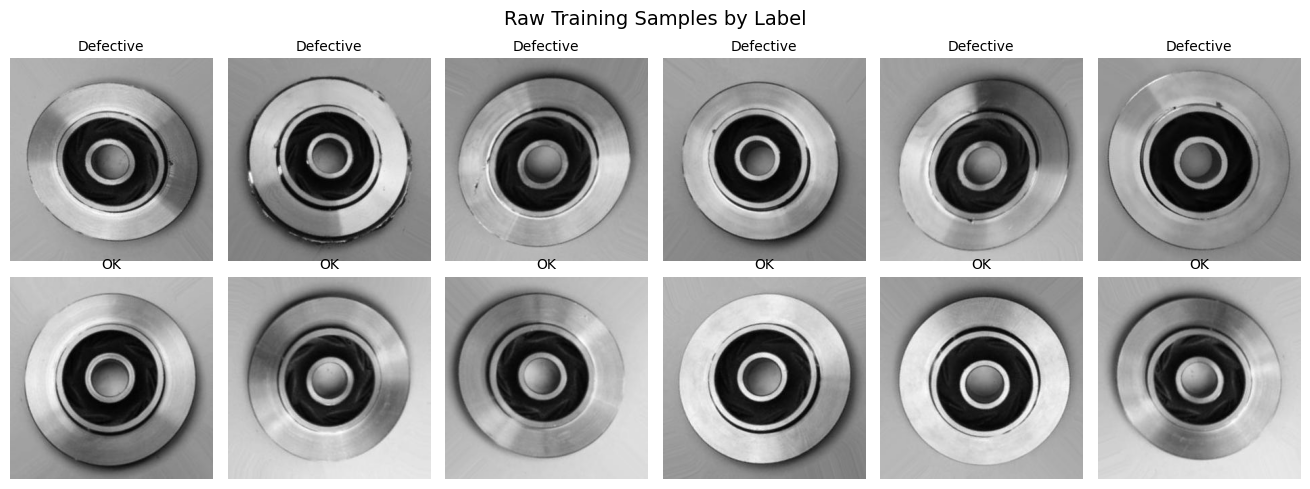

In [9]:
# Code Intent:
# Show representative OK and defective images for visual sanity checking.
# Key Ideas:
# - Read images through OpenCV and convert BGR to RGB for correct display.
# - Sample equally by class to avoid visual review being dominated by the larger class.
# - Use compact grids so senior reviewers can quickly assess lighting, fixture, and defect cues.

# Sample visualization

def read_rgb(path: str) -> np.ndarray:
    image = cv2.imread(path, cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f"Unreadable image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def plot_samples(df: pd.DataFrame, samples_per_class: int = 6, title: str = "Sample Images") -> None:
    min_count = int(df.groupby("display_label").size().min())
    n_per_class = min(samples_per_class, min_count)
    selected = (
        df.groupby("display_label", group_keys=False)
        .sample(n=n_per_class, random_state=SEED)
        .reset_index(drop=True)
    )
    cols = n_per_class
    rows = int(np.ceil(len(selected) / max(cols, 1)))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.5))
    axes = np.array(axes).reshape(-1)
    fig.suptitle(title, fontsize=14)
    for ax, (_, row) in zip(axes, selected.iterrows()):
        ax.imshow(read_rgb(row["path"]), cmap="gray")
        ax.set_title(row["display_label"], fontsize=10)
        ax.axis("off")
    for ax in axes[len(selected):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_samples(raw_train_df, samples_per_class=6, title="Raw Training Samples by Label")


### Defect Characteristics Discussion

The public labels should be treated conservatively. A classifier can learn genuine defect evidence, but it can also learn camera, lighting, fixture, background, compression, or augmentation artifacts. Production review must inspect false accepts and false rejects, and separate process-relevant casting evidence from image-acquisition shortcuts.


## 4. Preprocessing & Augmentation

Preprocessing must match deployment. Training augmentation improves robustness, but deployment preprocessing must stay deterministic, inspectable, and inexpensive on edge hardware.

Baseline preprocessing: OpenCV load, grayscale conversion, optional CLAHE, fixed resize, and 3-channel RGB conversion for ImageNet-pretrained ResNet compatibility.

Training augmentation remains manufacturing-relevant: small rotation/translation, mild brightness/contrast changes, occasional blur, and orientation-safe horizontal flips. Aggressive crops are avoided because they can erase small defects.


In [10]:
# Code Intent:
# Define deterministic preprocessing and lightweight diagnostics for edge deployment.
# Key Ideas:
# - Convert to grayscale because the dataset is effectively grayscale industrial imagery.
# - Apply CLAHE only through configuration so contrast normalization is explicit and reproducible.
# - Resize deterministically to the model input size and return 3-channel RGB for ImageNet ResNet weights.
# - Compute intensity, edge, and sharpness diagnostics for drift monitoring rather than using them as model inputs.

# OpenCV preprocessing and image-quality diagnostics

def preprocess_for_inspection(
    image_bgr: np.ndarray,
    output_size: int = TRAINING_CONFIG.image_size,
    config: PreprocessConfig = PREPROCESS_CONFIG,
) -> np.ndarray:
    '''
    Deterministic edge-compatible preprocessing.
    Returns RGB uint8 image with shape (output_size, output_size, 3).
    '''
    if image_bgr is None:
        raise ValueError("Input image is None")

    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY) if image_bgr.ndim == 3 else image_bgr

    if config.denoise:
        gray = cv2.fastNlMeansDenoising(gray, h=5)

    if config.use_clahe:
        clahe = cv2.createCLAHE(clipLimit=config.clahe_clip_limit, tileGridSize=config.clahe_tile_grid_size)
        gray = clahe.apply(gray)

    resized = cv2.resize(gray, (output_size, output_size), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)

def texture_diagnostics(image_bgr: np.ndarray) -> Dict[str, float]:
    '''
    Lightweight diagnostics for drift monitoring. These are not model features by default.
    '''
    if image_bgr is None:
        raise ValueError("Input image is None")
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY) if image_bgr.ndim == 3 else image_bgr
    edges = cv2.Canny(gray, threshold1=50, threshold2=150)
    laplacian_variance = cv2.Laplacian(gray, cv2.CV_64F).var()
    return {
        "mean_intensity": float(np.mean(gray)),
        "std_intensity": float(np.std(gray)),
        "edge_density": float(np.mean(edges > 0)),
        "laplacian_variance": float(laplacian_variance),
    }


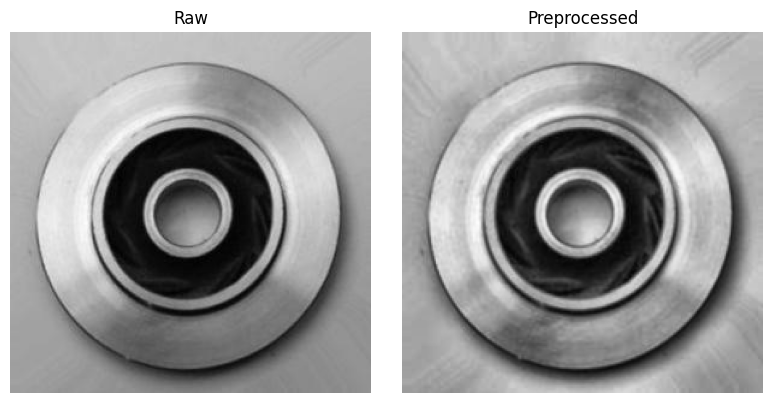

,mean_intensity,std_intensity,edge_density,laplacian_variance
0,142.365678,63.810556,0.041433,153.846708


Preprocessing contract validation passed.


In [11]:
# Code Intent:
# Verify preprocessing visually and programmatically before model training.
# Key Ideas:
# - Compare raw and processed images to catch destructive contrast or resizing choices.
# - Assert shape, dtype, value range, and finite values as a deployment contract.
# - Sample multiple images so preprocessing failures are caught before training begins.

# Preprocessing visual and contract checks

sample_path = raw_train_df.sample(1, random_state=SEED)["path"].iloc[0]
sample_bgr = cv2.imread(sample_path, cv2.IMREAD_COLOR)
sample_processed = preprocess_for_inspection(sample_bgr)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Raw")
axes[0].axis("off")
axes[1].imshow(sample_processed)
axes[1].set_title("Preprocessed")
axes[1].axis("off")
plt.tight_layout()
plt.show()

display(pd.DataFrame([texture_diagnostics(sample_bgr)]))

def validate_preprocessing(path: str) -> None:
    image = cv2.imread(path, cv2.IMREAD_COLOR)
    output = preprocess_for_inspection(image)
    assert output.shape == (TRAINING_CONFIG.image_size, TRAINING_CONFIG.image_size, 3), output.shape
    assert output.dtype == np.uint8, output.dtype
    assert output.min() >= 0 and output.max() <= 255
    assert np.isfinite(output).all()

for path in raw_train_df.sample(min(50, len(raw_train_df)), random_state=SEED)["path"]:
    validate_preprocessing(path)

print("Preprocessing contract validation passed.")


In [12]:
# Code Intent:
# Define train-time augmentation and eval-time normalization consistently.
# Key Ideas:
# - Use modest geometric and photometric augmentation aligned with manufacturing variation.
# - Avoid aggressive crops because they can remove small defects and corrupt labels.
# - Normalize with ImageNet statistics because the ResNet backbone uses ImageNet-pretrained weights.
# - Keep evaluation transforms deterministic so validation/test metrics reflect model behavior, not augmentation noise.

# TorchVision transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.RandomAffine(degrees=7, translate=(0.02, 0.02), scale=(0.97, 1.03)),
        transforms.RandomApply([transforms.ColorJitter(brightness=0.15, contrast=0.15)], p=0.5),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.15),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)


## 5. Baseline Classification Model

The baseline uses ResNet18 transfer learning. This is a conservative production-pilot choice: mature architecture, stable PyTorch/TorchVision implementation, fast batch-size-1 inference, straightforward export path, and direct compatibility with image-level labels.

The positive class is **defective**. Defect recall and false-accept count are primary governance metrics.


In [13]:
# Code Intent:
# Wrap the image inventory in a PyTorch Dataset and build loaders for training, validation, and test.
# Key Ideas:
# - Load every image through the same OpenCV preprocessing path intended for deployment.
# - Convert the preprocessed image into PIL only because TorchVision transforms expect that interface here.
# - Use a weighted sampler to reduce class imbalance pressure during training.
# - Keep validation and test loaders deterministic with shuffle disabled.

# Dataset and dataloaders

class CastingClassificationDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        transform=None,
        preprocess_config: PreprocessConfig = PREPROCESS_CONFIG,
    ):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.preprocess_config = preprocess_config

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]
        image_bgr = cv2.imread(row["path"], cv2.IMREAD_COLOR)
        if image_bgr is None:
            raise ValueError(f"Unreadable image: {row['path']}")
        image_rgb = preprocess_for_inspection(
            image_bgr,
            output_size=TRAINING_CONFIG.image_size,
            config=self.preprocess_config,
        )
        image_pil = Image.fromarray(image_rgb)
        image_tensor = self.transform(image_pil) if self.transform else transforms.ToTensor()(image_pil)
        label = torch.tensor(int(row["label"]), dtype=torch.long)
        return image_tensor, label

def make_weighted_sampler(df: pd.DataFrame) -> WeightedRandomSampler:
    label_counts = df["label"].value_counts().to_dict()
    sample_weights = df["label"].map(lambda label: 1.0 / label_counts[int(label)]).values
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )

train_dataset = CastingClassificationDataset(train_df, transform=train_transform)
val_dataset = CastingClassificationDataset(val_df, transform=eval_transform)
test_dataset = CastingClassificationDataset(test_df, transform=eval_transform)

train_sampler = make_weighted_sampler(train_df) if TRAINING_CONFIG.use_weighted_sampler else None

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAINING_CONFIG.batch_size,
    sampler=train_sampler,
    shuffle=train_sampler is None,
    num_workers=TRAINING_CONFIG.num_workers,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=TRAINING_CONFIG.batch_size,
    shuffle=False,
    num_workers=TRAINING_CONFIG.num_workers,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=TRAINING_CONFIG.batch_size,
    shuffle=False,
    num_workers=TRAINING_CONFIG.num_workers,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")


Train batches: 177
Val batches:   32
Test batches:  18


In [14]:
# Code Intent:
# Define the ResNet classifier, optimization policy, and reusable metric functions.
# Key Ideas:
# - Replace the ImageNet classification head with a two-class inspection head.
# - Keep optional backbone freezing available for low-data or fast-pilot experiments.
# - Use AdamW with cosine scheduling as a stable transfer-learning baseline.
# - Report defect precision, recall, and F1 explicitly because accuracy alone is insufficient for inspection.
# - Keep confusion-matrix formatting standardized for review and acceptance reports.

# Model, loss, optimizer, and core metric utilities

def build_resnet18_classifier(num_classes: int = 2, freeze_backbone: bool = False) -> nn.Module:
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)
    if freeze_backbone:
        for parameter in model.parameters():
            parameter.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(p=0.2), nn.Linear(in_features, num_classes))
    return model

def make_loss(df: pd.DataFrame) -> nn.Module:
    if not TRAINING_CONFIG.use_class_weighted_loss:
        return nn.CrossEntropyLoss()
    label_counts = df["label"].value_counts().sort_index()
    weights = torch.tensor([1.0 / label_counts.get(i, 1) for i in range(2)], dtype=torch.float32)
    weights = weights / weights.sum() * 2
    return nn.CrossEntropyLoss(weight=weights.to(DEVICE))

model = build_resnet18_classifier(num_classes=2, freeze_backbone=False).to(DEVICE)
criterion = make_loss(train_df)
optimizer = torch.optim.AdamW(model.parameters(), lr=TRAINING_CONFIG.learning_rate, weight_decay=TRAINING_CONFIG.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(TRAINING_CONFIG.epochs, 1))

def compute_binary_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_defect": precision_score(y_true, y_pred, pos_label=TRAINING_CONFIG.defect_positive_label, zero_division=0),
        "recall_defect": recall_score(y_true, y_pred, pos_label=TRAINING_CONFIG.defect_positive_label, zero_division=0),
        "f1_defect": f1_score(y_true, y_pred, pos_label=TRAINING_CONFIG.defect_positive_label, zero_division=0),
    }

def confusion_matrix_df(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return pd.DataFrame(matrix, index=["Actual OK", "Actual Defective"], columns=["Predicted OK", "Predicted Defective"])

model.fc


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 70.7MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=512, out_features=2, bias=True)
)

In [15]:
# Code Intent:
# Train the classifier and retain the validation-best checkpoint.
# Key Ideas:
# - Train with standard supervised cross-entropy over image-level labels.
# - Select checkpoints using a defect-recall-heavy score because false accepts are the key quality risk.
# - Preserve the best model state in memory before threshold governance and final test evaluation.
# - Keep prediction output as true labels, argmax labels, and probabilities so threshold analysis is possible.

# Training and prediction loops

def train_one_epoch(model: nn.Module, loader: DataLoader) -> Dict[str, float]:
    model.train()
    running_loss = 0.0
    total = 0
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        total += batch_size
    return {"loss": running_loss / max(total, 1)}

@torch.no_grad()
def predict_loader(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        probabilities = torch.softmax(logits, dim=1)
        predictions = torch.argmax(probabilities, dim=1)
        y_true.append(labels.cpu().numpy())
        y_pred.append(predictions.cpu().numpy())
        y_prob.append(probabilities.cpu().numpy())
    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(y_prob)

history = []
best_state = None
best_score = -np.inf

for epoch in range(1, TRAINING_CONFIG.epochs + 1):
    train_metrics = train_one_epoch(model, train_loader)
    scheduler.step()
    val_true_argmax, val_pred_argmax, val_prob_argmax = predict_loader(model, val_loader)
    val_metrics_argmax = compute_binary_metrics(val_true_argmax, val_pred_argmax)
    selection_score = val_metrics_argmax["recall_defect"] * 10.0 + val_metrics_argmax["f1_defect"]
    if selection_score > best_score:
        best_score = selection_score
        best_state = copy.deepcopy(model.state_dict())
    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "lr": scheduler.get_last_lr()[0],
        **{f"val_argmax_{key}": value for key, value in val_metrics_argmax.items()},
    }
    history.append(row)
    print(row)

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
display(history_df)


{'epoch': 1, 'train_loss': 0.08701123334910112, 'lr': 9.045084971874738e-05, 'val_argmax_accuracy': 0.9959798994974874, 'val_argmax_precision_defect': 1.0, 'val_argmax_recall_defect': 0.9929078014184397, 'val_argmax_f1_defect': 0.99644128113879}
{'epoch': 2, 'train_loss': 0.020040267080718762, 'lr': 6.545084971874737e-05, 'val_argmax_accuracy': 0.9969849246231156, 'val_argmax_precision_defect': 1.0, 'val_argmax_recall_defect': 0.9946808510638298, 'val_argmax_f1_defect': 0.9973333333333333}
{'epoch': 3, 'train_loss': 0.016859391140419514, 'lr': 3.454915028125263e-05, 'val_argmax_accuracy': 0.9979899497487437, 'val_argmax_precision_defect': 1.0, 'val_argmax_recall_defect': 0.9964539007092199, 'val_argmax_f1_defect': 0.9982238010657194}
{'epoch': 4, 'train_loss': 0.00912075937625996, 'lr': 9.549150281252631e-06, 'val_argmax_accuracy': 0.9979899497487437, 'val_argmax_precision_defect': 1.0, 'val_argmax_recall_defect': 0.9964539007092199, 'val_argmax_f1_defect': 0.9982238010657194}
{'epoch'

,epoch,train_loss,lr,val_argmax_accuracy,val_argmax_precision_defect,val_argmax_recall_defect,val_argmax_f1_defect
0,1,0.087011,0.000090,0.995980,1.0,0.992908,0.996441
1,2,0.020040,0.000065,0.996985,1.0,0.994681,0.997333
2,3,0.016859,0.000035,0.997990,1.0,0.996454,0.998224
3,4,0.009121,0.000010,0.997990,1.0,0.996454,0.998224
4,5,0.008532,0.000000,0.997990,1.0,0.996454,0.998224


In [16]:
# Code Intent:
# Convert model probabilities into a governed inspection operating point.
# Key Ideas:
# - Sweep thresholds on validation data rather than accepting default argmax behavior.
# - Select a conservative threshold that meets defect-recall policy while minimizing defective parts accepted as OK.
# - Add ROC-AUC, PR-AUC, Brier score, confidence intervals, and false-accept-rate framing.
# - Store threshold policy as data so the chosen operating point can be versioned with artifacts.

# Advanced evaluation, calibration, threshold governance, and uncertainty bands

def wilson_interval(successes: int, total: int, z: float = 1.96) -> Tuple[float, float]:
    if total <= 0:
        return (np.nan, np.nan)
    p_hat = successes / total
    denominator = 1.0 + z**2 / total
    center = (p_hat + z**2 / (2 * total)) / denominator
    half_width = z * math.sqrt((p_hat * (1.0 - p_hat) + z**2 / (4 * total)) / total) / denominator
    return (float(max(0.0, center - half_width)), float(min(1.0, center + half_width)))

def compute_advanced_metrics(y_true: np.ndarray, defect_prob: np.ndarray, threshold: float) -> Dict[str, float]:
    y_pred = (defect_prob >= threshold).astype(int)
    metrics = compute_binary_metrics(y_true, y_pred)
    defect_mask = y_true == TRAINING_CONFIG.defect_positive_label
    ok_mask = y_true != TRAINING_CONFIG.defect_positive_label
    false_accepts = int((defect_mask & (y_pred == 0)).sum())
    false_rejects = int((ok_mask & (y_pred == 1)).sum())
    defect_support = int(defect_mask.sum())
    ok_support = int(ok_mask.sum())
    if len(np.unique(y_true)) > 1:
        metrics["roc_auc"] = roc_auc_score(y_true, defect_prob)
        metrics["pr_auc"] = average_precision_score(y_true, defect_prob)
    else:
        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan
    metrics["brier_score"] = brier_score_loss(y_true, defect_prob)
    metrics["false_accepts"] = false_accepts
    metrics["false_rejects"] = false_rejects
    metrics["defect_support"] = defect_support
    metrics["ok_support"] = ok_support
    metrics["false_accept_rate"] = false_accepts / max(defect_support, 1)
    metrics["false_reject_rate"] = false_rejects / max(ok_support, 1)
    metrics["threshold"] = float(threshold)
    return metrics

def compute_metric_confidence_intervals(y_true: np.ndarray, defect_prob: np.ndarray, threshold: float) -> pd.DataFrame:
    y_pred = (defect_prob >= threshold).astype(int)
    defect_mask = y_true == TRAINING_CONFIG.defect_positive_label
    ok_mask = y_true != TRAINING_CONFIG.defect_positive_label
    tp = int((defect_mask & (y_pred == 1)).sum())
    fn = int((defect_mask & (y_pred == 0)).sum())
    fp = int((ok_mask & (y_pred == 1)).sum())
    tn = int((ok_mask & (y_pred == 0)).sum())
    rows = []
    for metric_name, successes, total in [
        ("defect_recall", tp, tp + fn),
        ("false_accept_rate", fn, tp + fn),
        ("ok_accept_rate", tn, tn + fp),
        ("false_reject_rate", fp, tn + fp),
    ]:
        low, high = wilson_interval(successes, total)
        estimate = successes / total if total else np.nan
        rows.append(
            {
                "metric": metric_name,
                "estimate": estimate,
                "ci95_low": low,
                "ci95_high": high,
                "successes": successes,
                "total": total,
            }
        )
    return pd.DataFrame(rows)

def evaluate_thresholds(y_true: np.ndarray, defect_prob: np.ndarray) -> pd.DataFrame:
    rows = []
    thresholds = np.linspace(0.01, 0.99, TRAINING_CONFIG.threshold_grid_points)
    for threshold in thresholds:
        rows.append(compute_advanced_metrics(y_true, defect_prob, threshold))
    return pd.DataFrame(rows)

val_true, val_pred_argmax, val_prob = predict_loader(model, val_loader)
test_true, test_pred_argmax, test_prob = predict_loader(model, test_loader)

val_threshold_df = evaluate_thresholds(val_true, val_prob[:, TRAINING_CONFIG.defect_positive_label])
display(val_threshold_df.sort_values(["false_accepts", "false_rejects", "threshold"], ascending=[True, True, True]).head(15))

eligible = val_threshold_df[val_threshold_df["recall_defect"] >= TRAINING_CONFIG.defect_recall_target]
if len(eligible):
    selected = eligible.sort_values(["false_accepts", "false_rejects", "threshold"], ascending=[True, True, True]).iloc[0]
else:
    selected = val_threshold_df.sort_values(["recall_defect", "f1_defect"], ascending=[False, False]).iloc[0]

OPERATING_THRESHOLD = float(selected["threshold"])
threshold_policy = {
    "positive_class": "def_front",
    "objective": "minimize defective parts accepted as OK while controlling OK parts sent to review",
    "defect_recall_target": TRAINING_CONFIG.defect_recall_target,
    "selected_threshold": OPERATING_THRESHOLD,
    "selected_from_split": "validation",
    "selection_sort_order": ["false_accepts ascending", "false_rejects ascending", "threshold ascending for conservative defect-recall margin"],
}
print(json.dumps(threshold_policy, indent=2))
RUN_MANIFEST["threshold_policy"] = json_safe(threshold_policy)

val_metrics = compute_advanced_metrics(val_true, val_prob[:, TRAINING_CONFIG.defect_positive_label], OPERATING_THRESHOLD)
test_metrics = compute_advanced_metrics(test_true, test_prob[:, TRAINING_CONFIG.defect_positive_label], OPERATING_THRESHOLD)
metrics_summary_df = pd.DataFrame(
    [
        {"split": "validation", **val_metrics},
        {"split": "test", **test_metrics},
    ]
)
display(metrics_summary_df)

val_ci_df = compute_metric_confidence_intervals(val_true, val_prob[:, TRAINING_CONFIG.defect_positive_label], OPERATING_THRESHOLD).assign(split="validation")
test_ci_df = compute_metric_confidence_intervals(test_true, test_prob[:, TRAINING_CONFIG.defect_positive_label], OPERATING_THRESHOLD).assign(split="test")
metric_confidence_df = pd.concat([val_ci_df, test_ci_df], ignore_index=True)[["split", "metric", "estimate", "ci95_low", "ci95_high", "successes", "total"]]
display(metric_confidence_df)
RUN_MANIFEST["metric_confidence_intervals"] = metric_confidence_df.to_dict(orient="records")

print("Validation report")
print(classification_report(val_true, (val_prob[:, 1] >= OPERATING_THRESHOLD).astype(int), target_names=[DISPLAY_NAMES[0], DISPLAY_NAMES[1]], zero_division=0))
display(confusion_matrix_df(val_true, (val_prob[:, 1] >= OPERATING_THRESHOLD).astype(int)))
print("Test report")
print(classification_report(test_true, (test_prob[:, 1] >= OPERATING_THRESHOLD).astype(int), target_names=[DISPLAY_NAMES[0], DISPLAY_NAMES[1]], zero_division=0))
display(confusion_matrix_df(test_true, (test_prob[:, 1] >= OPERATING_THRESHOLD).astype(int)))
print(
    "Inspection framing: false accepts are defective parts predicted OK; "
    "false rejects are OK parts routed to defective/review."
)


,accuracy,precision_defect,recall_defect,f1_defect,roc_auc,pr_auc,brier_score,false_accepts,false_rejects,defect_support,ok_support,false_accept_rate,false_reject_rate,threshold
2,1.000000,1.000000,1.000000,1.000000,1.0,1.0,0.001754,0,0,564,431,0.000000,0.000000,0.031778
3,1.000000,1.000000,1.000000,1.000000,1.0,1.0,0.001754,0,0,564,431,0.000000,0.000000,0.042667
1,0.997990,0.996466,1.000000,0.998230,1.0,1.0,0.001754,0,2,564,431,0.000000,0.004640,0.020889
0,0.994975,0.991213,1.000000,0.995587,1.0,1.0,0.001754,0,5,564,431,0.000000,0.011601,0.010000
4,0.998995,1.000000,0.998227,0.999113,1.0,1.0,0.001754,1,0,564,431,0.001773,0.000000,0.053556
5,0.998995,1.000000,0.998227,0.999113,1.0,1.0,0.001754,1,0,564,431,0.001773,0.000000,0.064444
6,0.998995,1.000000,0.998227,0.999113,1.0,1.0,0.001754,1,0,564,431,0.001773,0.000000,0.075333
7,0.998995,1.000000,0.998227,0.999113,1.0,1.0,0.001754,1,0,564,431,0.001773,0.000000,0.086222
8,0.998995,1.000000,0.998227,0.999113,1.0,1.0,0.001754,1,0,564,431,0.001773,0.000000,0.097111
9,0.998995,1.000000,0.998227,0.999113,1.0,1.0,0.001754,1,0,564,431,0.001773,0.000000,0.108000


{
  "positive_class": "def_front",
  "objective": "minimize defective parts accepted as OK while controlling OK parts sent to review",
  "defect_recall_target": 0.95,
  "selected_threshold": 0.03177777777777778,
  "selected_from_split": "validation",
  "selection_sort_order": [
    "false_accepts ascending",
    "false_rejects ascending",
    "threshold ascending for conservative defect-recall margin"
  ]
}


,split,accuracy,precision_defect,recall_defect,f1_defect,roc_auc,pr_auc,brier_score,false_accepts,false_rejects,defect_support,ok_support,false_accept_rate,false_reject_rate,threshold
0,validation,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,0.001754,0,0,564,431,0.0,0.000000,0.031778
1,test,0.992995,0.990315,1.0,0.995134,0.999864,0.999947,0.004337,0,4,409,162,0.0,0.024691,0.031778


,split,metric,estimate,ci95_low,ci95_high,successes,total
0,validation,defect_recall,1.000000,0.993235,1.000000,564,564
1,validation,false_accept_rate,0.000000,0.000000,0.006765,0,564
2,validation,ok_accept_rate,1.000000,0.991166,1.000000,431,431
3,validation,false_reject_rate,0.000000,0.000000,0.008834,0,431
4,test,defect_recall,1.000000,0.990695,1.000000,409,409
5,test,false_accept_rate,0.000000,0.000000,0.009305,0,409
6,test,ok_accept_rate,0.975309,0.938240,0.990357,158,162
7,test,false_reject_rate,0.024691,0.009643,0.061760,4,162


Validation report
              precision    recall  f1-score   support

          OK       1.00      1.00      1.00       431
   Defective       1.00      1.00      1.00       564

    accuracy                           1.00       995
   macro avg       1.00      1.00      1.00       995
weighted avg       1.00      1.00      1.00       995



,Predicted OK,Predicted Defective
Actual OK,431,0
Actual Defective,0,564


Test report
              precision    recall  f1-score   support

          OK       1.00      0.98      0.99       162
   Defective       0.99      1.00      1.00       409

    accuracy                           0.99       571
   macro avg       1.00      0.99      0.99       571
weighted avg       0.99      0.99      0.99       571



,Predicted OK,Predicted Defective
Actual OK,158,4
Actual Defective,0,409


Inspection framing: false accepts are defective parts predicted OK; false rejects are OK parts routed to defective/review.


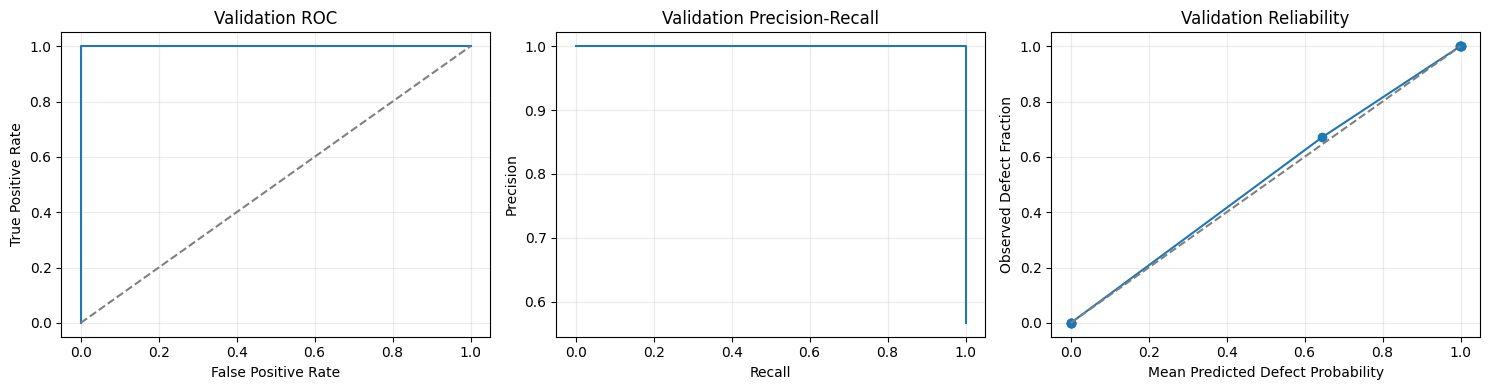

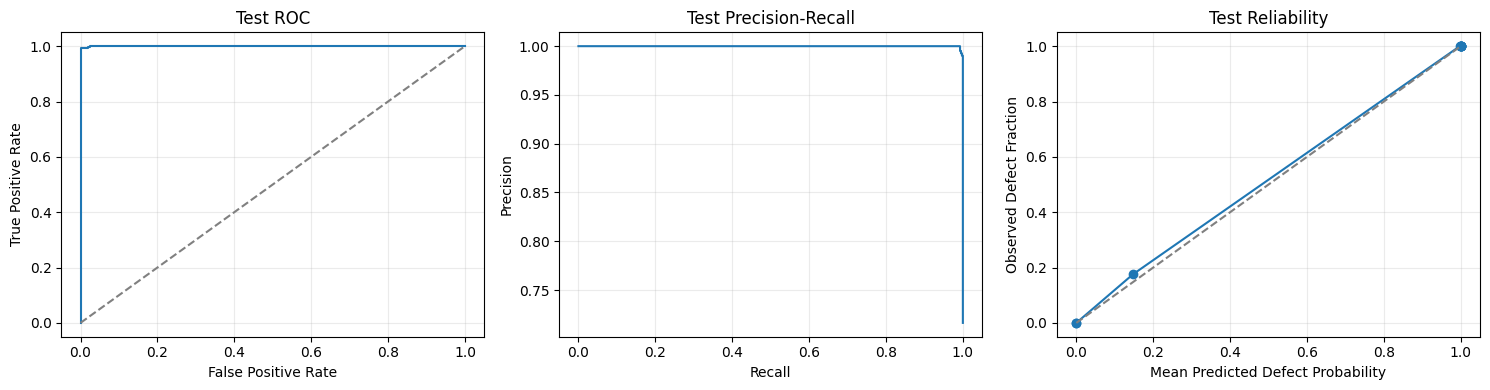

In [17]:
# Code Intent:
# Visualize ranking and calibration behavior beyond scalar metrics.
# Key Ideas:
# - ROC shows separability across thresholds but can be optimistic under imbalance.
# - Precision-recall is more informative when defect/OK proportions are uneven.
# - Reliability curves show whether predicted defect probabilities are calibrated enough for threshold governance.
# - Plot validation and test curves separately to reveal overfitting or split shift.

# ROC, precision-recall, and reliability curve data

def plot_metric_curves(y_true: np.ndarray, defect_prob: np.ndarray, title_prefix: str) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    if len(np.unique(y_true)) > 1:
        fpr, tpr, _ = roc_curve(y_true, defect_prob)
        precision, recall, _ = precision_recall_curve(y_true, defect_prob)
        axes[0].plot(fpr, tpr)
        axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
        axes[0].set_title(f"{title_prefix} ROC")
        axes[0].set_xlabel("False Positive Rate")
        axes[0].set_ylabel("True Positive Rate")
        axes[1].plot(recall, precision)
        axes[1].set_title(f"{title_prefix} Precision-Recall")
        axes[1].set_xlabel("Recall")
        axes[1].set_ylabel("Precision")

    prob_true, prob_pred = calibration_curve(y_true, defect_prob, n_bins=10, strategy="quantile")
    axes[2].plot(prob_pred, prob_true, marker="o")
    axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[2].set_title(f"{title_prefix} Reliability")
    axes[2].set_xlabel("Mean Predicted Defect Probability")
    axes[2].set_ylabel("Observed Defect Fraction")

    for ax in axes:
        ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_metric_curves(val_true, val_prob[:, TRAINING_CONFIG.defect_positive_label], "Validation")
plot_metric_curves(test_true, test_prob[:, TRAINING_CONFIG.defect_positive_label], "Test")


,error_type,count
0,correct,567
1,false_reject,4


,path,file_name,display_label,defect_probability,pred_display,error_type,decision_margin,review_priority
17,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1368.jpeg,OK,0.415996,Defective,false_reject,0.384218,0.415996
135,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_7839.jpeg,OK,0.359795,Defective,false_reject,0.328017,0.359795
123,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_62.jpeg,OK,0.258671,Defective,false_reject,0.226893,0.258671
6,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1316.jpeg,OK,0.072284,Defective,false_reject,0.040506,0.072284


,path,file_name,display_label,defect_probability,pred_display,error_type,decision_margin,review_priority
43,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_259.jpeg,OK,0.031445,OK,correct,0.000332,0.989542
93,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_2911.jpeg,OK,0.028176,OK,correct,0.003602,0.886663
279,/kaggle/input/real-life-industrial-dataset-of-...,cast_def_0_1591.jpeg,Defective,0.045880,Defective,correct,0.014102,0.556237
27,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1426.jpeg,OK,0.011362,OK,correct,0.020416,0.357554
153,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_9926.jpeg,OK,0.007109,OK,correct,0.024669,0.223708
87,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_2869.jpeg,OK,0.007066,OK,correct,0.024711,0.222368
20,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1382.jpeg,OK,0.006012,OK,correct,0.025765,0.189201
76,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_2810.jpeg,OK,0.004130,OK,correct,0.027647,0.129974
143,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_8010.jpeg,OK,0.002886,OK,correct,0.028892,0.090813
125,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_6401.jpeg,OK,0.002658,OK,correct,0.029119,0.083653


No examples available for False Accept Review Grid.


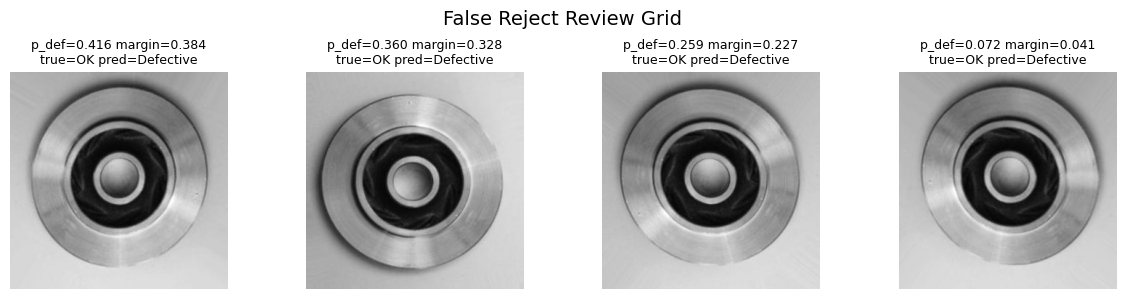

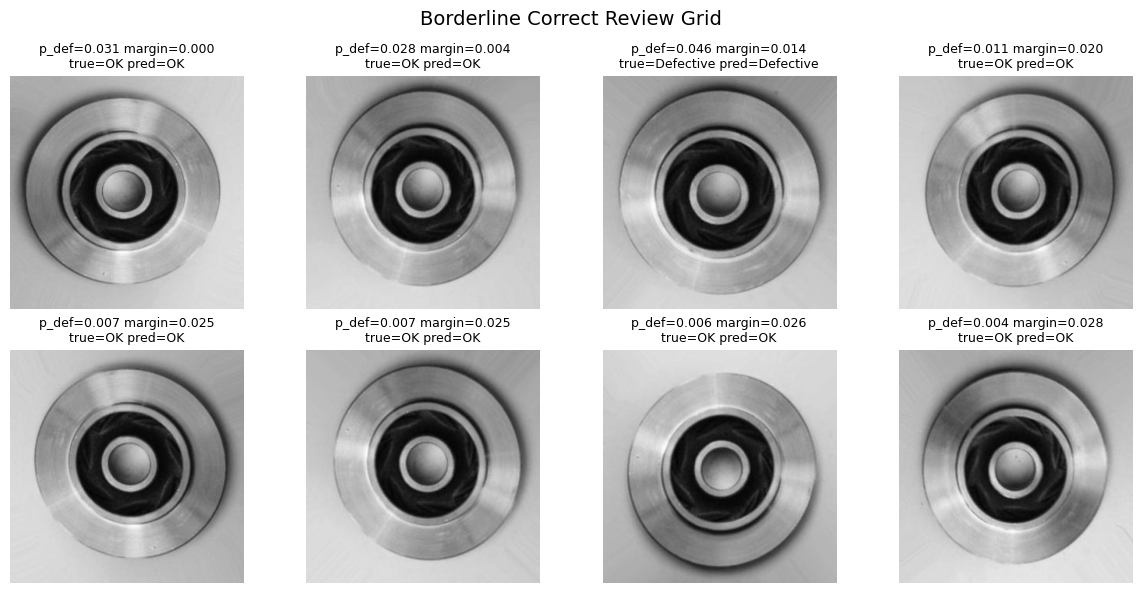

In [18]:
# Code Intent:
# Turn model errors and borderline decisions into reviewable quality-engineering evidence.
# Key Ideas:
# - Build a row-level prediction table with probabilities, decisions, margins, and error type.
# - Prioritize false accepts, false rejects, and borderline correct decisions because they drive release risk and review load.
# - Visual grids help reviewers distinguish real model failures from label noise or acquisition artifacts.
# - Keep paths in the table so images can be traced back to source data.

# False-accept / false-reject / borderline review tables and visual grids

def build_prediction_frame(df: pd.DataFrame, y_true: np.ndarray, defect_prob: np.ndarray, threshold: float) -> pd.DataFrame:
    pred_df = df.reset_index(drop=True).copy()
    pred_df["true_label"] = y_true
    pred_df["defect_probability"] = defect_prob
    pred_df["pred_label"] = (defect_prob >= threshold).astype(int)
    pred_df["pred_display"] = pred_df["pred_label"].map(DISPLAY_NAMES)
    pred_df["error_type"] = "correct"
    pred_df.loc[(pred_df["true_label"] == 1) & (pred_df["pred_label"] == 0), "error_type"] = "false_accept"
    pred_df.loc[(pred_df["true_label"] == 0) & (pred_df["pred_label"] == 1), "error_type"] = "false_reject"
    pred_df["decision_margin"] = (pred_df["defect_probability"] - threshold).abs()
    pred_df["review_priority"] = 0.0
    pred_df.loc[pred_df["error_type"] == "false_accept", "review_priority"] = 1.0 - pred_df["defect_probability"]
    pred_df.loc[pred_df["error_type"] == "false_reject", "review_priority"] = pred_df["defect_probability"]
    pred_df.loc[pred_df["error_type"] == "correct", "review_priority"] = 1.0 - np.minimum(pred_df["decision_margin"] / max(threshold, 1e-6), 1.0)
    return pred_df

def plot_review_grid_from_frame(subset: pd.DataFrame, title: str, n: int = 12) -> None:
    subset = subset.head(n)
    if subset.empty:
        print(f"No examples available for {title}.")
        return
    cols = min(4, len(subset))
    rows = int(math.ceil(len(subset) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.0, rows * 3.0))
    axes = np.array(axes).reshape(-1)
    fig.suptitle(title, fontsize=14)
    for ax, (_, row) in zip(axes, subset.iterrows()):
        ax.imshow(read_rgb(row["path"]), cmap="gray")
        ax.set_title(
            f"p_def={row['defect_probability']:.3f} margin={row['decision_margin']:.3f}\n"
            f"true={row['display_label']} pred={row['pred_display']}",
            fontsize=9,
        )
        ax.axis("off")
    for ax in axes[len(subset):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def plot_review_grid(pred_df: pd.DataFrame, error_type: str, n: int = 12) -> None:
    subset = pred_df[pred_df["error_type"] == error_type].sort_values("review_priority", ascending=False)
    plot_review_grid_from_frame(subset, f"{error_type.replace('_', ' ').title()} Review Grid", n=n)

def plot_borderline_correct_grid(pred_df: pd.DataFrame, n: int = 8) -> None:
    subset = pred_df[pred_df["error_type"] == "correct"].sort_values("decision_margin", ascending=True)
    plot_review_grid_from_frame(subset, "Borderline Correct Review Grid", n=n)

val_prediction_df = build_prediction_frame(val_df, val_true, val_prob[:, 1], OPERATING_THRESHOLD)
test_prediction_df = build_prediction_frame(test_df, test_true, test_prob[:, 1], OPERATING_THRESHOLD)

review_columns = [
    "path",
    "file_name",
    "display_label",
    "defect_probability",
    "pred_display",
    "error_type",
    "decision_margin",
    "review_priority",
]
review_summary_df = test_prediction_df.groupby("error_type").size().reset_index(name="count")
display(review_summary_df)
error_review_df = test_prediction_df[test_prediction_df["error_type"] != "correct"].sort_values("review_priority", ascending=False)
display(error_review_df[review_columns].head(25))

borderline_correct_df = test_prediction_df[test_prediction_df["error_type"] == "correct"].sort_values("decision_margin", ascending=True).head(12)
display(borderline_correct_df[review_columns])
plot_review_grid(test_prediction_df, "false_accept", n=8)
plot_review_grid(test_prediction_df, "false_reject", n=8)
plot_borderline_correct_grid(test_prediction_df, n=8)


### Explainability Diagnostics

Grad-CAM overlays can help reviewers see where the classifier is most sensitive. These overlays are diagnostic only. They do not prove causality, do not replace localized annotation, and should not be used as final defect evidence without human review.


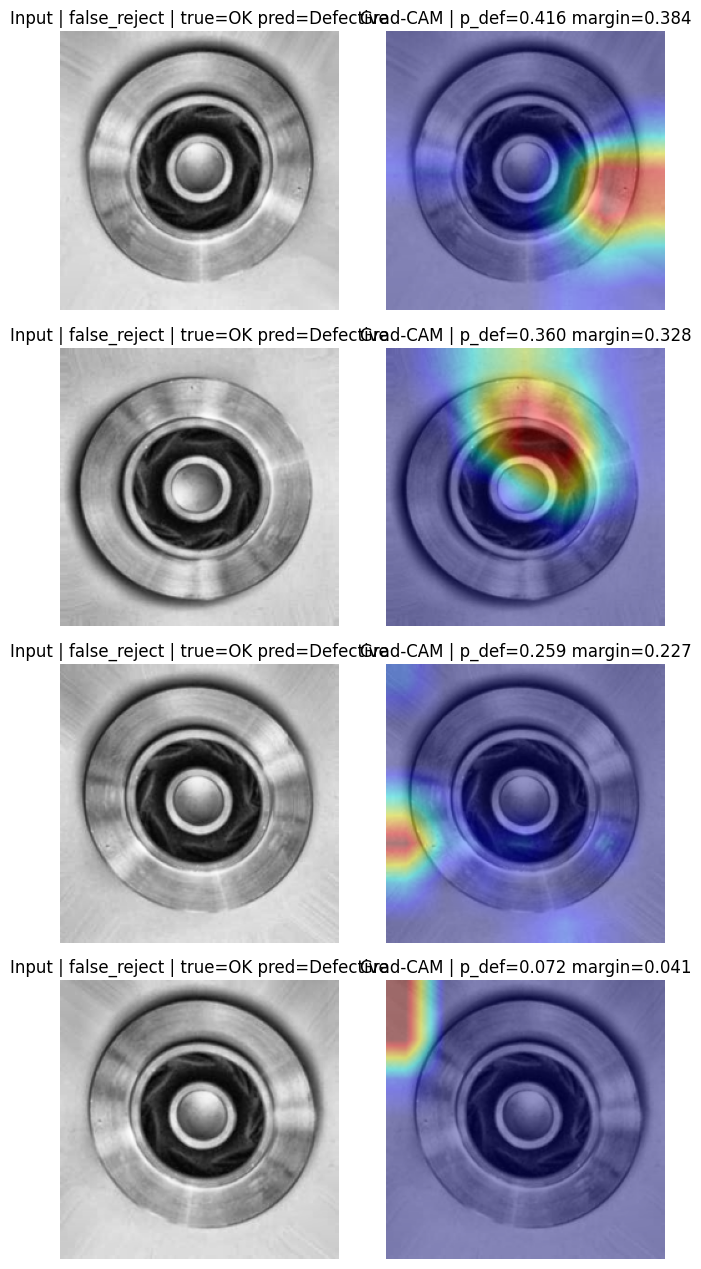

In [19]:
# Code Intent:
# Generate diagnostic heatmaps showing image regions that influence the ResNet defect score.
# Key Ideas:
# - Hook the final ResNet convolutional block to capture activations and gradients.
# - Weight activations by class-specific gradients to form a defect-class heatmap.
# - Overlay heatmaps on preprocessed images for reviewer inspection.
# - Prefer errors first, then high-risk borderline correct decisions if no errors are available.
# - Treat Grad-CAM as diagnostic support only, not as a substitute for localized labels or human evidence.
# - Remove hooks after plotting to avoid stale references in later notebook execution.

# Lightweight ResNet Grad-CAM diagnostics

class ResNetGradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self) -> None:
        self.forward_handle.remove()
        self.backward_handle.remove()

    def __call__(self, input_tensor: torch.Tensor, target_class: int) -> np.ndarray:
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)
        score = logits[:, target_class].sum()
        score.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        heatmap = cam.squeeze().detach().cpu().numpy()
        heatmap = heatmap - heatmap.min()
        heatmap = heatmap / (heatmap.max() + 1e-8)
        return heatmap

def tensor_for_path(path: str) -> torch.Tensor:
    image_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    image_rgb = preprocess_for_inspection(image_bgr)
    return eval_transform(Image.fromarray(image_rgb)).unsqueeze(0).to(DEVICE)

def overlay_heatmap(image_rgb: np.ndarray, heatmap: np.ndarray, alpha: float = 0.4) -> np.ndarray:
    resized_heatmap = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))
    color_heatmap = cv2.applyColorMap(np.uint8(255 * resized_heatmap), cv2.COLORMAP_JET)
    color_heatmap = cv2.cvtColor(color_heatmap, cv2.COLOR_BGR2RGB)
    overlay = np.clip((1 - alpha) * image_rgb + alpha * color_heatmap, 0, 255).astype(np.uint8)
    return overlay

def select_gradcam_review_examples(pred_df: pd.DataFrame, n: int = 6) -> pd.DataFrame:
    errors = pred_df[pred_df["error_type"] != "correct"].sort_values("review_priority", ascending=False)
    if len(errors):
        return errors.head(n)
    return pred_df.sort_values("decision_margin", ascending=True).head(n)

def plot_gradcam_examples(pred_df: pd.DataFrame, n: int = 6) -> None:
    review_df = select_gradcam_review_examples(pred_df, n=n)
    if review_df.empty:
        print("No examples available for Grad-CAM.")
        return

    gradcam = ResNetGradCAM(model.eval(), model.layer4)
    fig, axes = plt.subplots(len(review_df), 2, figsize=(7, 3.2 * len(review_df)))
    axes = np.array(axes).reshape(len(review_df), 2)
    try:
        for row_idx, (_, row) in enumerate(review_df.iterrows()):
            image_rgb = preprocess_for_inspection(cv2.imread(row["path"], cv2.IMREAD_COLOR))
            tensor = tensor_for_path(row["path"])
            heatmap = gradcam(tensor, target_class=TRAINING_CONFIG.defect_positive_label)
            axes[row_idx, 0].imshow(image_rgb)
            axes[row_idx, 0].set_title(f"Input | {row['error_type']} | true={row['display_label']} pred={row['pred_display']}")
            axes[row_idx, 0].axis("off")
            axes[row_idx, 1].imshow(overlay_heatmap(image_rgb, heatmap))
            axes[row_idx, 1].set_title(f"Grad-CAM | p_def={row['defect_probability']:.3f} margin={row['decision_margin']:.3f}")
            axes[row_idx, 1].axis("off")
    finally:
        gradcam.remove()
    plt.tight_layout()
    plt.show()

plot_gradcam_examples(test_prediction_df, n=4)


## 6. Ultralytics Integration Path

The current dataset is classification-only. Detection, segmentation, and OBB workflows require localized annotation first. The code below defines label contracts and validation helpers so later annotation conversion remains explicit and auditable.


In [20]:
# Code Intent:
# Define the future Ultralytics localization contract without pretending labels already exist.
# Key Ideas:
# - Keep base model names configurable through environment variables for YOLOv8+ workflows.
# - Validate expected YOLO image/label folder structure before training localized models.
# - Validate detection rows, segmentation polygons, and OBB corners for normalized coordinates and known classes.
# - Separate annotation governance from classifier training because image-level labels cannot create boxes or masks.

# YOLO dataset contract and label validators

ULTRALYTICS_BASE_MODEL = os.getenv("ULTRALYTICS_BASE_MODEL", "yolov8n.pt")
ULTRALYTICS_SEG_MODEL = os.getenv("ULTRALYTICS_SEG_MODEL", "yolov8n-seg.pt")
ULTRALYTICS_OBB_MODEL = os.getenv("ULTRALYTICS_OBB_MODEL", "yolov8n-obb.pt")

def write_simple_yaml(payload: Dict[str, object], output_path: Path) -> None:
    lines = []
    for key, value in payload.items():
        if isinstance(value, dict):
            lines.append(f"{key}:")
            for inner_key, inner_value in value.items():
                lines.append(f"  {inner_key}: {inner_value}")
        else:
            lines.append(f"{key}: {value}")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text("\n".join(lines) + "\n", encoding="utf-8")

def build_yolo_dataset_yaml(dataset_root: Path, class_names: Dict[int, str], output_path: Path) -> Dict[str, object]:
    payload = {"path": str(dataset_root), "train": "images/train", "val": "images/val", "test": "images/test", "names": class_names}
    write_simple_yaml(payload, output_path)
    return payload

def validate_yolo_dataset_contract(dataset_root: Path) -> Dict[str, bool]:
    required = {
        "images_train": dataset_root / "images" / "train",
        "images_val": dataset_root / "images" / "val",
        "labels_train": dataset_root / "labels" / "train",
        "labels_val": dataset_root / "labels" / "val",
    }
    return {name: path.exists() for name, path in required.items()}

def assert_normalized(values: Iterable[float], name: str) -> None:
    bad_values = [float(value) for value in values if not (0.0 <= float(value) <= 1.0)]
    if bad_values:
        raise ValueError(f"{name} contains values outside [0, 1]: {bad_values[:5]}")

def validate_detection_row(row: Tuple[int, float, float, float, float]) -> None:
    class_id, x_center, y_center, width, height = row
    if class_id not in DEFECT_CLASSES:
        raise ValueError(f"Unknown class id: {class_id}")
    assert_normalized([x_center, y_center, width, height], "Detection row")
    if width <= 0 or height <= 0:
        raise ValueError("Detection width and height must be positive.")

def validate_segmentation_row(row: Tuple[int, Sequence[Tuple[float, float]]]) -> None:
    class_id, polygon = row
    if class_id not in DEFECT_CLASSES:
        raise ValueError(f"Unknown class id: {class_id}")
    if len(polygon) < 3:
        raise ValueError("Segmentation polygon requires at least 3 points.")
    assert_normalized([coord for xy in polygon for coord in xy], "Segmentation polygon")

def validate_obb_row(row: Tuple[int, Sequence[Tuple[float, float]]]) -> None:
    class_id, corners = row
    if class_id not in DEFECT_CLASSES:
        raise ValueError(f"Unknown class id: {class_id}")
    if len(corners) != 4:
        raise ValueError("OBB row requires exactly 4 corners.")
    assert_normalized([coord for xy in corners for coord in xy], "OBB corners")

example_contract = validate_yolo_dataset_contract(Path("datasets/casting_yolo_detect"))
display(pd.DataFrame([example_contract]))


,images_train,images_val,labels_train,labels_val
0,False,False,False,False


In [21]:
# Code Intent:
# Provide controlled command templates for future YOLO detection, segmentation, OBB, and export work.
# Key Ideas:
# - Keep commands visible as reviewable deployment recipes rather than executing them implicitly.
# - Use the configured model names so teams can swap approved Ultralytics variants.
# - Include an INT8 TensorRT export example tied to a calibration dataset YAML.
# - Make the path from annotation to edge export explicit for later production extension.

# Ultralytics train/export command matrix

ultralytics_commands = {
    "detect_train": f"yolo detect train model={ULTRALYTICS_BASE_MODEL} data=datasets/casting_yolo_detect/data.yaml imgsz=640 epochs=100 batch=16",
    "segment_train": f"yolo segment train model={ULTRALYTICS_SEG_MODEL} data=datasets/casting_yolo_segment/data.yaml imgsz=640 epochs=100 batch=16",
    "obb_train": f"yolo obb train model={ULTRALYTICS_OBB_MODEL} data=datasets/casting_yolo_obb/data.yaml imgsz=640 epochs=100 batch=16",
    "detect_export_tensorrt_int8": "yolo export model=runs/detect/train/weights/best.pt format=engine int8=True data=datasets/casting_yolo_detect/data.yaml",
}

display(pd.DataFrame([{"operation": key, "command": value} for key, value in ultralytics_commands.items()]))


,operation,command
0,detect_train,yolo detect train model=yolov8n.pt data=datase...
1,segment_train,yolo segment train model=yolov8n-seg.pt data=d...
2,obb_train,yolo obb train model=yolov8n-obb.pt data=datas...
3,detect_export_tensorrt_int8,yolo export model=runs/detect/train/weights/be...


## 7. Edge Optimization Considerations

Edge readiness requires measuring the full station path: acquisition, transfer, validation, preprocessing, inference, thresholding, postprocessing, logging, and station I/O. Batch-size-1 p95 latency is the governing number.

INT8, TensorRT, OpenVINO, or ONNX Runtime should be selected only after parity and defect-recall checks pass on representative plant imagery.


In [22]:
# Code Intent:
# Measure edge-relevant single-image inference behavior.
# Key Ideas:
# - Define a single-image prediction wrapper that includes preprocessing and thresholding.
# - Benchmark batch-size-1 pipeline latency because station decisions happen one part at a time.
# - Report p95 latency against a configurable budget rather than relying on average latency.
# - Synchronize CUDA timing when applicable so GPU timings are meaningful.

# Batch-size-1 edge latency benchmark

@torch.no_grad()
def predict_single_image(path: str, threshold: float = OPERATING_THRESHOLD) -> Dict[str, object]:
    model.eval()
    image_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    image_rgb = preprocess_for_inspection(image_bgr)
    tensor = eval_transform(Image.fromarray(image_rgb)).unsqueeze(0).to(DEVICE)
    start = time.perf_counter()
    logits = model(tensor)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    model_latency_ms = (time.perf_counter() - start) * 1000
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()[0]
    defect_probability = float(probabilities[TRAINING_CONFIG.defect_positive_label])
    predicted_label = int(defect_probability >= threshold)
    return {
        "path": path,
        "predicted_label": DISPLAY_NAMES[predicted_label],
        "defect_probability": defect_probability,
        "threshold": threshold,
        "latency_ms_model_only": model_latency_ms,
    }

@torch.no_grad()
def benchmark_single_image_pipeline(model: nn.Module, sample_paths: Sequence[str]) -> pd.DataFrame:
    model.eval()
    paths = list(sample_paths)
    if not paths:
        raise ValueError("No sample paths provided.")
    for i in range(EDGE_CONFIG.benchmark_warmup):
        _ = predict_single_image(paths[i % len(paths)], threshold=OPERATING_THRESHOLD)
    timings = []
    for i in range(EDGE_CONFIG.benchmark_repeats):
        path = paths[i % len(paths)]
        start = time.perf_counter()
        _ = predict_single_image(path, threshold=OPERATING_THRESHOLD)
        timings.append((time.perf_counter() - start) * 1000)
    return pd.DataFrame({"pipeline_latency_ms": timings})

latency_sample_paths = test_df.sample(min(16, len(test_df)), random_state=SEED)["path"].tolist()
latency_df = benchmark_single_image_pipeline(model, latency_sample_paths)
latency_summary = latency_df.describe(percentiles=[0.5, 0.9, 0.95, 0.99])
latency_p95_ms = float(latency_df["pipeline_latency_ms"].quantile(0.95))
latency_budget_passed = latency_p95_ms <= EDGE_CONFIG.p95_latency_budget_ms
display(latency_summary)
print(f"p95 latency: {latency_p95_ms:.2f} ms | budget: {EDGE_CONFIG.p95_latency_budget_ms:.2f} ms | passed={latency_budget_passed}")


,pipeline_latency_ms
count,50.000000
mean,7.499226
std,0.402024
min,6.953262
50%,7.507948
90%,7.808921
95%,8.266615
99%,8.727941
max,8.765647


p95 latency: 8.27 ms | budget: 50.00 ms | passed=True


In [23]:
# Code Intent:
# Package the model decision system only when explicitly enabled.
# Key Ideas:
# - Keep artifact saving off by default to prevent accidental filesystem churn during review.
# - Save model weights, threshold policy, label map, manifest, and metrics together for traceability.
# - Export ONNX only when requested and when optional dependencies are available.
# - Track actual artifact and parity status instead of inferring success from configuration flags.

# Artifact save, ONNX export, and optional ONNX Runtime parity check

def write_json(path: Path, payload: Dict[str, object]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(json_safe(payload), indent=2), encoding="utf-8")

def build_artifact_status() -> Dict[str, object]:
    return {
        "artifact_root": str(ARTIFACT_CONFIG.root),
        "save_requested": bool(ARTIFACT_CONFIG.save_artifacts),
        "export_onnx_requested": bool(ARTIFACT_CONFIG.export_onnx),
        "onnx_parity_requested": bool(ARTIFACT_CONFIG.validate_onnx_parity),
        "model_state_saved": False,
        "metadata_saved": False,
        "onnx_exported": False,
        "onnx_parity_checked": False,
        "onnx_parity_passed": False,
        "onnx_max_abs_diff": None,
        "notes": [],
    }

artifact_status = build_artifact_status()
artifact_payload = {
    "manifest": RUN_MANIFEST,
    "threshold_policy": threshold_policy,
    "label_map": INDEX_TO_CLASS,
    "metrics": metrics_summary_df.to_dict(orient="records"),
    "metric_confidence_intervals": metric_confidence_df.to_dict(orient="records"),
    "latency": {
        "p95_ms": latency_p95_ms,
        "budget_ms": EDGE_CONFIG.p95_latency_budget_ms,
        "passed": latency_budget_passed,
    },
}

if ARTIFACT_CONFIG.save_artifacts:
    ARTIFACT_CONFIG.root.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), ARTIFACT_CONFIG.root / "model.pt")
    write_json(ARTIFACT_CONFIG.root / "threshold.json", threshold_policy)
    write_json(ARTIFACT_CONFIG.root / "label_map.json", INDEX_TO_CLASS)
    write_json(ARTIFACT_CONFIG.root / "manifest.json", RUN_MANIFEST)
    write_json(ARTIFACT_CONFIG.root / "artifact_payload.json", artifact_payload)
    metrics_summary_df.to_csv(ARTIFACT_CONFIG.root / "metrics.csv", index=False)
    artifact_status["model_state_saved"] = True
    artifact_status["metadata_saved"] = True
    artifact_status["notes"].append("Model and metadata artifacts saved.")
    print(f"Saved model artifacts under {ARTIFACT_CONFIG.root.resolve()}")
else:
    artifact_status["notes"].append("Artifact saving disabled by configuration.")
    print("Artifact saving disabled. Set SAVE_CASTING_ARTIFACTS=true to write model.pt, threshold.json, label_map.json, manifest.json, artifact_payload.json, and metrics.csv.")

ONNX_PATH = ARTIFACT_CONFIG.root / "casting_resnet18_classifier.onnx"
if ARTIFACT_CONFIG.export_onnx:
    if importlib.util.find_spec("onnx") is None:
        artifact_status["notes"].append("ONNX export skipped because the optional 'onnx' package is not installed.")
        print("ONNX export skipped because the optional 'onnx' package is not installed.")
    else:
        ARTIFACT_CONFIG.root.mkdir(parents=True, exist_ok=True)
        model.eval()
        dummy_input = torch.randn(1, 3, TRAINING_CONFIG.image_size, TRAINING_CONFIG.image_size, device=DEVICE)
        torch.onnx.export(
            model,
            dummy_input,
            str(ONNX_PATH),
            input_names=["image"],
            output_names=["logits"],
            dynamic_axes=None,
            opset_version=17,
        )
        artifact_status["onnx_exported"] = True
        artifact_status["notes"].append(f"Exported ONNX model: {ONNX_PATH.resolve()}")
        print(f"Exported ONNX model: {ONNX_PATH.resolve()}")

        if ARTIFACT_CONFIG.validate_onnx_parity and importlib.util.find_spec("onnxruntime") is not None:
            import onnxruntime as ort

            session = ort.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])
            with torch.no_grad():
                pt_logits = model(dummy_input).detach().cpu().numpy()
            ort_logits = session.run(None, {"image": dummy_input.detach().cpu().numpy()})[0]
            max_abs_diff = float(np.max(np.abs(pt_logits - ort_logits)))
            artifact_status["onnx_parity_checked"] = True
            artifact_status["onnx_max_abs_diff"] = max_abs_diff
            artifact_status["onnx_parity_passed"] = max_abs_diff <= 1e-4
            print(f"ONNX parity max_abs_diff={max_abs_diff:.6f} | passed={artifact_status['onnx_parity_passed']}")
        elif ARTIFACT_CONFIG.validate_onnx_parity:
            artifact_status["notes"].append("ONNX parity skipped because optional 'onnxruntime' is not installed.")
            print("ONNX parity skipped because optional 'onnxruntime' is not installed.")
else:
    artifact_status["notes"].append("ONNX export disabled by configuration.")
    print(f"ONNX export disabled. Set EXPORT_CASTING_ONNX=true to export {ONNX_PATH}.")

RUN_MANIFEST["artifact_status"] = json_safe(artifact_status)
display(pd.DataFrame([artifact_status]).drop(columns=["notes"]))
print(json.dumps({"artifact_notes": artifact_status["notes"]}, indent=2))


Artifact saving disabled. Set SAVE_CASTING_ARTIFACTS=true to write model.pt, threshold.json, label_map.json, manifest.json, artifact_payload.json, and metrics.csv.
ONNX export disabled. Set EXPORT_CASTING_ONNX=true to export artifacts/casting_inspection/casting_resnet18_classifier.onnx.


,artifact_root,save_requested,export_onnx_requested,onnx_parity_requested,model_state_saved,metadata_saved,onnx_exported,onnx_parity_checked,onnx_parity_passed,onnx_max_abs_diff
0,artifacts/casting_inspection,False,False,True,False,False,False,False,False,None


{
  "artifact_notes": [
    "Artifact saving disabled by configuration.",
    "ONNX export disabled by configuration."
  ]
}


## 8. Retraining & Drift Handling Strategy

Production retraining should be driven by station telemetry, human review, downstream escapes, and drift indicators rather than fixed calendar retraining alone.

Version together: dataset snapshot, label schema, preprocessing code, training code, model weights, threshold, export artifact, calibration data, validation report, and rollback artifact.


In [24]:
# Code Intent:
# Specify what production inference logs should contain and how review queues can be prioritized.
# Key Ideas:
# - Include station metadata, model version, preprocessing version, threshold, probability, decision, diagnostics, and latency.
# - Build one example log record so the schema is concrete and testable.
# - Score review priority by uncertainty around the threshold because borderline cases are most informative.
# - Keep operator override fields in the schema because human-in-the-loop feedback is part of retraining.

# Production inference log schema and review prioritization

INFERENCE_LOG_COLUMNS = [
    "event_id",
    "timestamp_utc",
    "plant_id",
    "line_id",
    "station_id",
    "camera_id",
    "part_number",
    "model_version",
    "preprocess_version",
    "threshold",
    "defect_probability",
    "decision",
    "operator_override",
    "override_reason",
    "image_uri",
    "mean_intensity",
    "std_intensity",
    "edge_density",
    "laplacian_variance",
    "latency_ms",
]

def build_inference_log_record(
    image_path: str,
    prediction: Dict[str, object],
    station_metadata: Dict[str, str],
) -> Dict[str, object]:
    image_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
    diagnostics = texture_diagnostics(image_bgr) if image_bgr is not None else {}
    return {
        "event_id": hashlib.sha1(f"{image_path}-{time.time()}".encode("utf-8")).hexdigest()[:16],
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "model_version": station_metadata.get("model_version", MODEL_VERSION),
        "preprocess_version": station_metadata.get("preprocess_version", PREPROCESS_VERSION),
        "threshold": prediction.get("threshold"),
        "defect_probability": prediction.get("defect_probability"),
        "decision": prediction.get("predicted_label"),
        "operator_override": None,
        "override_reason": None,
        "image_uri": image_path,
        "latency_ms": prediction.get("latency_ms_model_only"),
        **{key: station_metadata.get(key) for key in ["plant_id", "line_id", "station_id", "camera_id", "part_number"]},
        **diagnostics,
    }

def review_priority_score(record: Dict[str, object]) -> float:
    probability = float(record.get("defect_probability", 0.5))
    threshold = float(record.get("threshold", OPERATING_THRESHOLD))
    uncertainty = 1.0 - min(abs(probability - threshold) / max(threshold, 1e-6), 1.0)
    return float(uncertainty)

example_prediction = predict_single_image(test_df.iloc[0]["path"], threshold=OPERATING_THRESHOLD)
example_log_record = build_inference_log_record(
    test_df.iloc[0]["path"],
    example_prediction,
    {
        "plant_id": "pilot_plant",
        "line_id": "casting_line_01",
        "station_id": "vision_station_01",
        "camera_id": "top_view_01",
        "part_number": "public_impeller_reference",
    },
)
example_log_record["review_priority"] = review_priority_score(example_log_record)
display(pd.DataFrame([example_log_record], columns=INFERENCE_LOG_COLUMNS + ["review_priority"]))


,event_id,timestamp_utc,plant_id,line_id,station_id,camera_id,part_number,model_version,preprocess_version,threshold,...,decision,operator_override,override_reason,image_uri,mean_intensity,std_intensity,edge_density,laplacian_variance,latency_ms,review_priority
0,bb053fc8a972a227,2026-05-01T02:26:32.243093+00:00,pilot_plant,casting_line_01,vision_station_01,top_view_01,public_impeller_reference,resnet18-imagelevel-public-pilot-v1,opencv-clahe-v2,0.031778,...,OK,None,None,/kaggle/input/real-life-industrial-dataset-of-...,138.967456,61.914225,0.045156,277.378987,4.020802,0.000113


In [25]:
# Code Intent:
# Provide lightweight dataset drift monitoring using image-quality features.
# Key Ideas:
# - Extract intensity, contrast, edge density, and sharpness diagnostics from sampled final split images.
# - Use Population Stability Index to compare current data against a final training reference distribution.
# - Interpret PSI with review bands so the number becomes an alerting signal, not an automatic retraining decision.
# - Display feature distributions by class to help separate visual drift from label mix changes.

# Drift monitoring features and PSI checks

def extract_monitoring_features(df: pd.DataFrame, sample_size: Optional[int] = 500) -> pd.DataFrame:
    working_df = df.copy()
    if sample_size is not None:
        working_df = working_df.sample(min(sample_size, len(working_df)), random_state=SEED)
    rows = []
    for _, row in working_df.iterrows():
        image_bgr = cv2.imread(row["path"], cv2.IMREAD_COLOR)
        if image_bgr is None:
            continue
        rows.append(
            {
                "path": row["path"],
                "split": row.get("model_split", row.get("split", "unknown")),
                "label": row["label"],
                "display_label": row["display_label"],
                **texture_diagnostics(image_bgr),
            }
        )
    return pd.DataFrame(rows)

def population_stability_index(
    expected: np.ndarray,
    actual: np.ndarray,
    bins: int = 10,
    epsilon: float = 1e-6,
) -> float:
    breakpoints = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(breakpoints) < 3:
        return 0.0
    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)
    expected_pct = np.maximum(expected_counts / max(expected_counts.sum(), 1), epsilon)
    actual_pct = np.maximum(actual_counts / max(actual_counts.sum(), 1), epsilon)
    return float(np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)))

def interpret_psi(value: float) -> str:
    if value < 0.10:
        return "stable"
    if value < 0.25:
        return "monitor"
    return "investigate"

train_monitor = extract_monitoring_features(train_df, sample_size=500)
test_monitor = extract_monitoring_features(test_df, sample_size=500)
psi_rows = []
for feature in ["mean_intensity", "std_intensity", "edge_density", "laplacian_variance"]:
    psi_value = population_stability_index(train_monitor[feature].values, test_monitor[feature].values)
    psi_rows.append(
        {
            "feature": feature,
            "psi_train_vs_test": psi_value,
            "interpretation": interpret_psi(psi_value),
        }
    )
psi_df = pd.DataFrame(psi_rows)
display(psi_df)
display(train_monitor.groupby("display_label")[["mean_intensity", "std_intensity", "edge_density", "laplacian_variance"]].describe())
RUN_MANIFEST["drift_monitoring"] = psi_df.to_dict(orient="records")


,feature,psi_train_vs_test,interpretation
0,mean_intensity,0.162970,monitor
1,std_intensity,0.193809,monitor
2,edge_density,0.130976,monitor
3,laplacian_variance,0.203481,monitor


mean_intensity                                                \
                       count        mean       std         min         25%   
display_label                                                                
Defective              274.0  139.726610  6.180578  124.910411  135.360219   
OK                     226.0  149.651886  6.248698  127.603744  143.056919   

                                                  std_intensity             \
                      50%         75%         max         count       mean   
display_label                                                                
Defective      139.432267  143.079622  156.586589         274.0  58.860906   
OK             151.660494  153.679567  159.256844         226.0  62.596573   

               ... edge_density           laplacian_variance              \
               ...          75%       max              count        mean   
display_label  ...                                                         
Defective      ...     0.049092  0.057244              274.0  185.869516   
OK             ...     0.043086  0.053511              226.0  170.077442   

                                                                         \
                     std        min         25%         50%         75%   
display_label                                                             
Defective      60.730994  69.970788  140.340282  184.082905  231.300026   
OK             75.152165  69.973788   91.345119  163.243938  223.139424   

                           
                      max  
display_label              
Defective      328.173255  
OK             435.900751  

[2 rows x 32 columns]

## 9. Risks & Mitigations

### Rare Defect Under-Representation

Risk: rare but high-cost defect modes may be absent. Mitigate with rare-defect review sets, downstream escape sampling, active learning, and localized labels for recurring high-cost defects. Low-data methods can be evaluated later as secondary support, not as an unvalidated production replacement.

### Overfitting to Visual Artifacts

Risk: the model may learn lighting, fixture, background, camera, compression, or augmentation artifacts. Mitigate with station-specific holdouts, hard negatives, image diagnostics, and false-decision review.

### Plant-to-Plant Variability

Risk: model performance may degrade across plants, suppliers, part variants, or camera stations. Mitigate with plant-level acceptance metrics, metadata capture, staged rollout, local calibration sets, and site-level rollback.

### Edge Deployment Failures

Risk: thermal throttling, camera faults, runtime mismatch, corrupt frames, or latency spikes. Mitigate with watchdogs, fail-safe routing, runtime versioning, health checks, and tested rollback.


## 10. Acceptance Criteria

### Technical Acceptance

- Dataset integrity checks pass.
- Preprocessing is deterministic and documented.
- Defect recall meets the agreed target on plant-specific holdout data.
- False accepts are reviewed and dispositioned.
- Threshold selection is risk-based and versioned.
- Batch-size-1 p95 latency meets station budget.
- Exported artifact matches PyTorch baseline within tolerance.
- Monitoring features and inference logs are available.

### Operational Acceptance

- Operators can challenge and override decisions.
- Review workflow exists for uncertain or disputed images.
- Model version and threshold are visible in station logs.
- Rollback procedure is tested.
- Maintenance has a documented recovery path.
- Plant quality engineering signs off on defect definitions and sampling.


In [26]:
# Code Intent:
# Convert acceptance criteria into an auditable checklist and final interview-facing executive summary.
# Key Ideas:
# - Combine data integrity, final leakage status, metric reporting, threshold selection, latency, artifacts, and operational readiness.
# - Mark plant-specific holdout and exported artifact validation explicitly false unless actually completed.
# - Compute checklist values from notebook state rather than hard-coding pass values.
# - State the release decision as pilot/reference-ready only, not production-approved.

# Acceptance checklist, release readiness, and executive summary

def build_release_readiness_summary() -> pd.DataFrame:
    final_filename_clean = leakage_summary["final_filename_leak_pairs"] == 0
    final_hash_clean = leakage_summary["final_hash_leak_pairs"] == 0
    rows = [
        {
            "criterion": "data_integrity_passed",
            "passed": audit_summary["unreadable_images"] == 0,
            "evidence": f"{audit_summary['scanned_images']} scanned, {audit_summary['unreadable_images']} unreadable",
        },
        {
            "criterion": "no_filename_leakage",
            "passed": final_filename_clean,
            "evidence": f"final filename overlap count={leakage_summary['final_filename_leak_pairs']}",
        },
        {
            "criterion": "no_exact_hash_leakage",
            "passed": final_hash_clean,
            "evidence": f"final SHA-1 overlap count={leakage_summary['final_hash_leak_pairs']}",
        },
        {
            "criterion": "preprocessing_contract_passed",
            "passed": "validate_preprocessing" in globals(),
            "evidence": f"{PREPROCESS_VERSION}, {TRAINING_CONFIG.image_size}x{TRAINING_CONFIG.image_size} RGB uint8 before tensor normalization",
        },
        {
            "criterion": "advanced_metrics_reported",
            "passed": {"roc_auc", "pr_auc", "brier_score", "false_accept_rate", "false_reject_rate"}.issubset(metrics_summary_df.columns),
            "evidence": "ROC-AUC, PR-AUC, Brier, false-accept, false-reject metrics computed",
        },
        {
            "criterion": "threshold_selected_for_defect_recall",
            "passed": "OPERATING_THRESHOLD" in globals() and val_metrics["recall_defect"] >= TRAINING_CONFIG.defect_recall_target,
            "evidence": f"threshold={OPERATING_THRESHOLD:.6f}, validation recall={val_metrics['recall_defect']:.6f}",
        },
        {
            "criterion": "test_defect_recall_meets_target",
            "passed": bool(test_metrics["recall_defect"] >= TRAINING_CONFIG.defect_recall_target),
            "evidence": f"test recall={test_metrics['recall_defect']:.6f}, target={TRAINING_CONFIG.defect_recall_target:.2f}",
        },
        {
            "criterion": "batch_size_one_latency_measured",
            "passed": "latency_p95_ms" in globals(),
            "evidence": f"p95={latency_p95_ms:.2f} ms",
        },
        {
            "criterion": "latency_budget_passed",
            "passed": bool(latency_budget_passed),
            "evidence": f"budget={EDGE_CONFIG.p95_latency_budget_ms:.2f} ms",
        },
        {
            "criterion": "plant_specific_holdout_validated",
            "passed": False,
            "evidence": "Not available in public dataset; required before production release",
        },
        {
            "criterion": "exported_artifact_validated",
            "passed": bool(artifact_status.get("onnx_parity_passed")),
            "evidence": "ONNX/export parity only passes when export and parity check are actually executed",
        },
        {
            "criterion": "rollback_plan_documented",
            "passed": True,
            "evidence": "Model card and release gates require versioned rollback artifact",
        },
        {
            "criterion": "operator_review_workflow_defined",
            "passed": "review_priority" in test_prediction_df.columns and "operator_override" in INFERENCE_LOG_COLUMNS,
            "evidence": "Review priority and operator override fields are present",
        },
    ]
    return pd.DataFrame(rows)

release_readiness_summary = build_release_readiness_summary()
acceptance_criteria = dict(zip(release_readiness_summary["criterion"], release_readiness_summary["passed"]))

pilot_reference_gate_names = [
    "data_integrity_passed",
    "no_filename_leakage",
    "no_exact_hash_leakage",
    "preprocessing_contract_passed",
    "advanced_metrics_reported",
    "threshold_selected_for_defect_recall",
    "test_defect_recall_meets_target",
    "batch_size_one_latency_measured",
    "latency_budget_passed",
    "operator_review_workflow_defined",
]
pilot_reference_ready = all(bool(acceptance_criteria[name]) for name in pilot_reference_gate_names)
computed_notebook_release_status = "pilot_reference_ready_not_production_approved" if pilot_reference_ready else "pilot_reference_has_blockers"
production_approved = all(bool(value) for value in acceptance_criteria.values())

executive_summary_df = pd.DataFrame(
    [
        {"area": "Release decision", "value": computed_notebook_release_status},
        {"area": "Production approval", "value": bool(production_approved)},
        {"area": "Final test images", "value": int(len(test_df))},
        {"area": "Test defect recall", "value": f"{test_metrics['recall_defect']:.6f}"},
        {"area": "Test false accepts", "value": int(test_metrics["false_accepts"])},
        {"area": "Test false rejects", "value": int(test_metrics["false_rejects"])},
        {"area": "Operating threshold", "value": f"{OPERATING_THRESHOLD:.6f}"},
        {"area": "p95 batch-size-1 latency", "value": f"{latency_p95_ms:.2f} ms"},
        {"area": "Final leakage removals", "value": int(len(leakage_removals_df))},
        {"area": "Plant holdout validated", "value": False},
        {"area": "Exported artifact parity", "value": bool(artifact_status.get("onnx_parity_passed"))},
    ]
)

display(executive_summary_df)
display(release_readiness_summary)
RUN_MANIFEST["notebook_release_status"] = computed_notebook_release_status
RUN_MANIFEST["production_approved"] = bool(production_approved)
RUN_MANIFEST["release_readiness_summary"] = release_readiness_summary.to_dict(orient="records")
RUN_MANIFEST["executive_summary"] = executive_summary_df.to_dict(orient="records")


,area,value
0,Release decision,pilot_reference_ready_not_production_approved
1,Production approval,False
2,Final test images,571
3,Test defect recall,1.000000
4,Test false accepts,0
5,Test false rejects,4
6,Operating threshold,0.031778
7,p95 batch-size-1 latency,8.27 ms
8,Final leakage removals,144
9,Plant holdout validated,False


,criterion,passed,evidence
0,data_integrity_passed,True,"7348 scanned, 0 unreadable"
1,no_filename_leakage,True,final filename overlap count=0
2,no_exact_hash_leakage,True,final SHA-1 overlap count=0
3,preprocessing_contract_passed,True,"opencv-clahe-v2, 224x224 RGB uint8 before tens..."
4,advanced_metrics_reported,True,"ROC-AUC, PR-AUC, Brier, false-accept, false-re..."
5,threshold_selected_for_defect_recall,True,"threshold=0.031778, validation recall=1.000000"
6,test_defect_recall_meets_target,True,"test recall=1.000000, target=0.95"
7,batch_size_one_latency_measured,True,p95=8.27 ms
8,latency_budget_passed,True,budget=50.00 ms
9,plant_specific_holdout_validated,False,Not available in public dataset; required befo...


### Model Card: Casting Inspection Baseline

**Intended use:** part-level OK/defective screening for controlled casting imagery in a pilot inspection workflow.

**Non-use:** final production release, safety certification, defect localization, severity scoring, supplier chargeback, or rework routing without plant-specific validation and additional localized labels.

**Training data:** public Kaggle casting inspection dataset with image-level binary labels.

**Known limits:** possible acquisition artifacts, unknown plant-to-plant generalization, limited defect taxonomy, no bounding boxes or masks, and potential repeated/augmented samples.

**Decision policy:** threshold selected on validation data to prioritize defective-part recall and reduce false accepts.

**Edge target:** batch-size-1 inference with deterministic OpenCV preprocessing and explicit fail-safe routing for unreadable or failed inference events.

**Release gates:** plant-specific holdout pass, false-accept review, latency benchmark pass, artifact parity check, rollback test, operator review workflow, and quality engineering approval.


## 11. Test Strategy

### Unit-Level Tests

Validate folder structure, class mapping, image readability, preprocessing output shape/range, file leakage, average-hash duplicate risk, and metric calculation.

### Model-Level Tests

Validate one-batch overfit behavior, metric reporting, threshold sensitivity, calibration, false accepts, false rejects, and Grad-CAM diagnostic generation.

### System-Level Tests

Validate batch-size-1 inference, latency budget, corrupt-frame handling, exported model parity, logging schema, watchdog behavior, artifact versioning, and rollback.


In [27]:
# Code Intent:
# Run lightweight notebook tests and define safe station behavior for failed inference.
# Key Ideas:
# - Re-check dataset structure, final split leakage, metric math, preprocessing, threshold policy, and YOLO label validators.
# - Fail-safe prediction routes unreadable or failed images to manual review rather than accepting the part.
# - Return a structured failure payload so station software can log and act on failures consistently.
# - Keep this cell near the end so it validates the full set of notebook definitions.

# Notebook-level tests and fail-safe inference wrapper

def safe_inspection_predict(path: str, threshold: float = OPERATING_THRESHOLD) -> Dict[str, object]:
    """
    Fail-safe station wrapper. If loading or inference fails, route to manual review rather than accepting the part.
    """
    try:
        return {"status": "model_decision", **predict_single_image(path, threshold=threshold)}
    except Exception as exc:
        return {
            "status": "manual_review_required",
            "path": path,
            "reason": str(exc),
            "predicted_label": "Defective",
            "defect_probability": 1.0,
            "threshold": threshold,
        }

def test_expected_dataset_structure(root: Path) -> None:
    for split in ["train", "test"]:
        for class_name in CLASS_TO_INDEX:
            expected = root / split / class_name
            assert expected.exists(), f"Missing expected folder: {expected}"

def test_no_split_leakage(train_frame: pd.DataFrame, val_frame: pd.DataFrame, test_frame: pd.DataFrame) -> None:
    assert_no_filename_leakage(("train", train_frame), ("val", val_frame), ("test", test_frame))
    assert_no_hash_leakage(("train", train_frame), ("val", val_frame), ("test", test_frame))

def test_metric_calculation_contract() -> None:
    y_true_contract = np.array([0, 0, 1, 1])
    y_pred_contract = np.array([0, 1, 1, 1])
    metrics = compute_binary_metrics(y_true_contract, y_pred_contract)
    assert np.isclose(metrics["accuracy"], 0.75)
    assert np.isclose(metrics["precision_defect"], 2 / 3)
    assert np.isclose(metrics["recall_defect"], 1.0)
    assert np.isclose(metrics["f1_defect"], 0.8)

def test_threshold_policy_contract() -> None:
    assert threshold_policy["selected_from_split"] == "validation"
    assert val_metrics["recall_defect"] >= TRAINING_CONFIG.defect_recall_target
    assert test_metrics["recall_defect"] >= TRAINING_CONFIG.defect_recall_target
    assert test_metrics["false_accept_rate"] <= 1.0 - TRAINING_CONFIG.defect_recall_target + 1e-12

def test_prediction_frame_alignment() -> None:
    assert len(test_prediction_df) == len(test_df)
    assert np.array_equal(test_prediction_df["true_label"].values, test_true)
    assert {"decision_margin", "review_priority", "error_type"}.issubset(test_prediction_df.columns)

def test_fail_safe_inference_wrapper() -> None:
    failed = safe_inspection_predict("nonexistent_image.png")
    assert failed["status"] == "manual_review_required"
    assert failed["predicted_label"] == "Defective"
    assert failed["defect_probability"] == 1.0

def test_acceptance_checklist_contract() -> None:
    assert acceptance_criteria["no_filename_leakage"]
    assert acceptance_criteria["no_exact_hash_leakage"]
    assert acceptance_criteria["threshold_selected_for_defect_recall"]
    assert acceptance_criteria["test_defect_recall_meets_target"]
    assert acceptance_criteria["plant_specific_holdout_validated"] is False
    assert acceptance_criteria["exported_artifact_validated"] == bool(artifact_status.get("onnx_parity_passed"))

def run_notebook_tests() -> None:
    test_expected_dataset_structure(DATA_ROOT)
    test_no_split_leakage(train_df, val_df, test_df)
    test_metric_calculation_contract()
    test_threshold_policy_contract()
    test_prediction_frame_alignment()
    test_fail_safe_inference_wrapper()
    test_acceptance_checklist_contract()
    sampled_paths = dataset_df.sample(min(25, len(dataset_df)), random_state=SEED)["path"]
    for path in sampled_paths:
        validate_preprocessing(path)
    validate_detection_row((0, 0.5, 0.5, 0.2, 0.2))
    validate_segmentation_row((0, [(0.1, 0.1), (0.2, 0.1), (0.2, 0.2)]))
    validate_obb_row((0, [(0.1, 0.1), (0.2, 0.1), (0.2, 0.2), (0.1, 0.2)]))
    print("Notebook test suite passed.")

run_notebook_tests()
display(pd.DataFrame([safe_inspection_predict("nonexistent_image.png")]))


Notebook test suite passed.


,status,path,reason,predicted_label,defect_probability,threshold
0,manual_review_required,nonexistent_image.png,Input image is None,Defective,1.0,0.031778


## Closing Engineering Notes

This notebook includes dataset integrity controls, reproducibility metadata, final split leakage governance, risk-based thresholding, confidence intervals, calibration review, error and borderline-case review, explainability diagnostics, optional artifact/export governance, edge latency checks, drift strategy, acceptance gates, notebook-level tests, and a model card.

The classifier remains the correct first step because the public dataset is image-level only. YOLO detection, segmentation, and OBB should be introduced only after localized annotations exist and plant quality engineering approves the taxonomy.

The final notebook release decision is intentionally conservative: it can be used as a pilot/reference workflow, but it is not production-approved. Production release still requires plant-specific holdout validation, false-accept review with quality engineering, exported-runtime parity, rollback testing, and operational signoff.

### Reference Links

- Kaggle dataset: https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product
- Ultralytics dataset documentation: https://docs.ultralytics.com/datasets/
- Ultralytics export documentation: https://docs.ultralytics.com/modes/export/
- TorchVision ResNet18 documentation: https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html


In [28]:
import json

# Display the final RUN_MANIFEST for documentation
print(json.dumps(RUN_MANIFEST, indent=2, default=str))


{
  "workflow": "casting_inspection_industrial_workflow",
  "created_utc": "2026-05-01T02:21:16.467442+00:00",
  "seed": 42,
  "device": "cuda",
  "git_commit": null,
  "model_version": "resnet18-imagelevel-public-pilot-v1",
  "preprocess_version": "opencv-clahe-v2",
  "notebook_release_status": "pilot_reference_ready_not_production_approved",
  "leakage_policy": {
    "priority_order": [
      "train",
      "val",
      "test"
    ],
    "train_val_overlap_action": "remove_from_validation",
    "test_overlap_action": "remove_from_test",
    "filename_overlap": "drop_downstream_rows_matching_upstream_filenames",
    "exact_hash_overlap": "drop_downstream_rows_matching_upstream_sha1",
    "near_duplicate_overlap": "warn_and_review_only"
  },
  "package_versions": {
    "opencv-python": "4.13.0.92",
    "matplotlib": "3.10.0",
    "numpy": "2.0.2",
    "pandas": "2.2.2",
    "Pillow": "11.3.0",
    "scikit-learn": "1.6.1",
    "torch": "2.10.0+cu128",
    "torchvision": "0.25.0+cu128",
